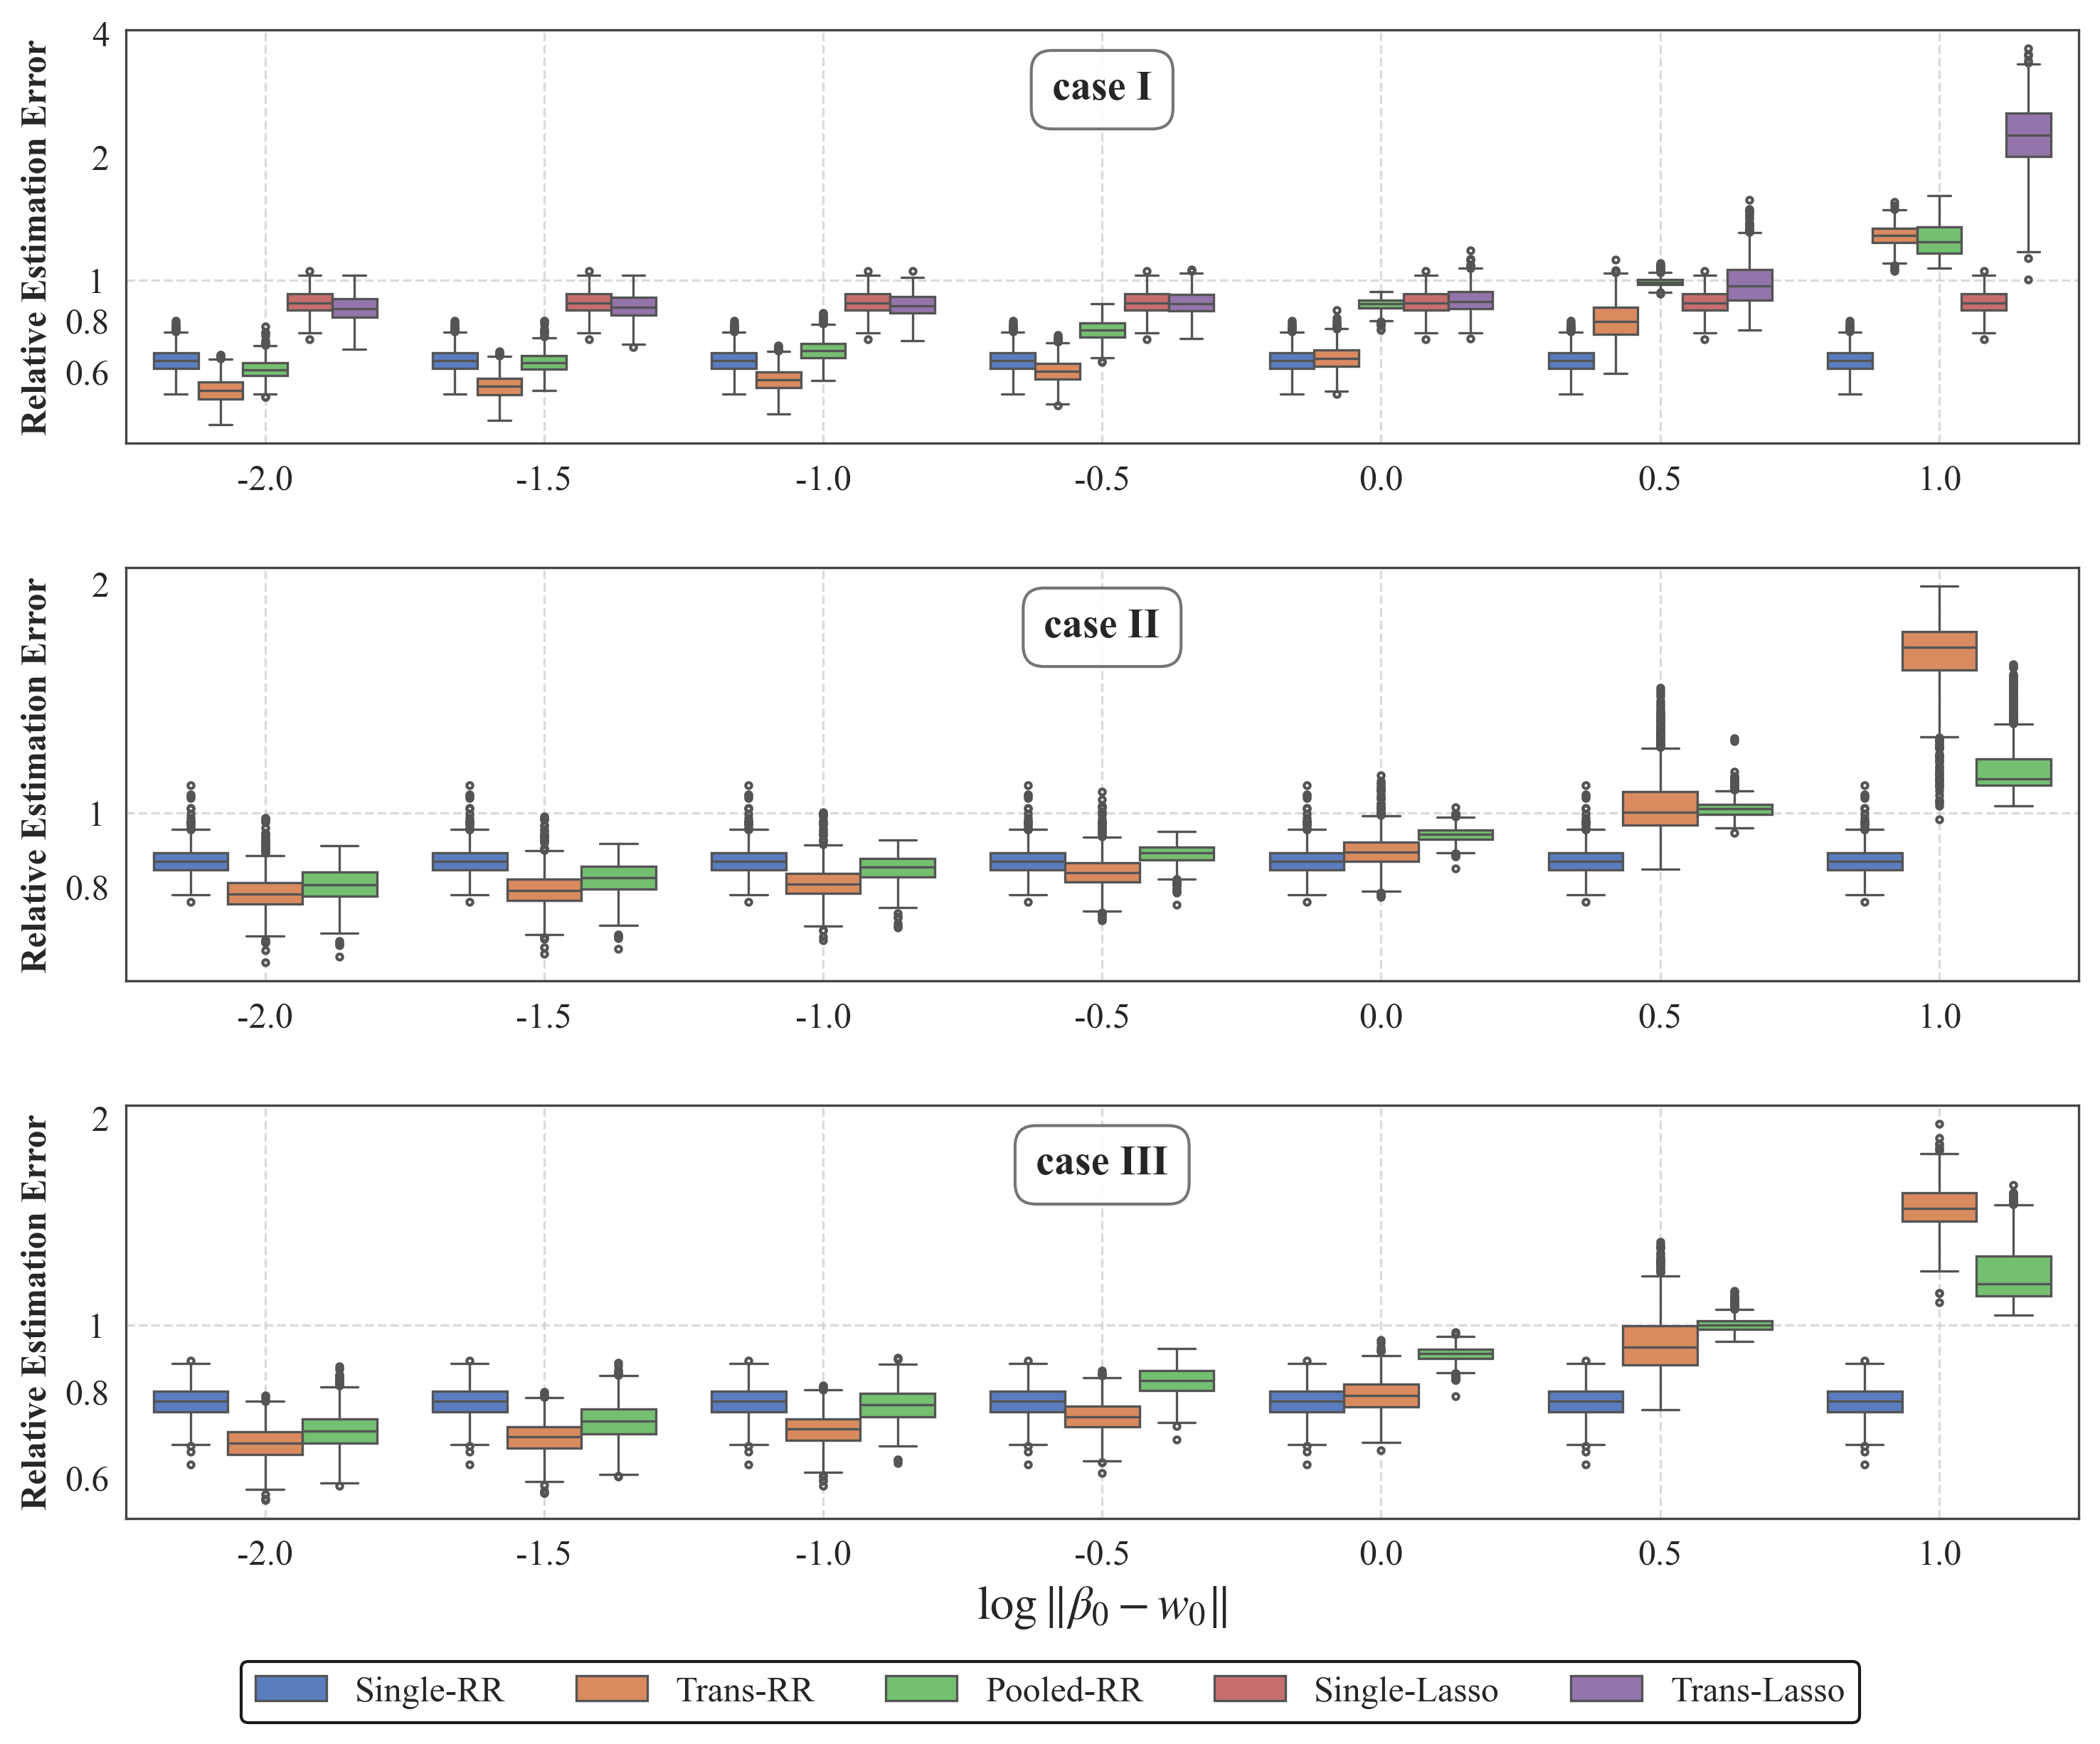

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
from matplotlib.ticker import LogLocator, LogFormatter, FuncFormatter

# 设置matplotlib的字体和样式
plt.rcParams.update({
'font.family': 'serif',
'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
'font.size': 12,
'mathtext.fontset': 'stix',
})

# 纯白色背景
bg_color = 'white'

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
'res/1gaussian_cv_results_p400_simu1000.json',
'res/1cauchy_cv_results_p400_simu1000.json',
'res/1mix_cv_results_p400_simu1000.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

# 方法名称映射
method_mapping = {
'Single RR': 'Single-RR',
'Trans RR': 'Trans-RR',
'Pooled RR': 'Pooled-RR',
'Single Lasso': 'Single-Lasso',
'Trans Lasso': 'Trans-Lasso'
}

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(dd_val) # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict: # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_mapping.get(method_name, method_name), # 转换方法名称
                            'error': error_val
                        })
        else: # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_mapping.get(method_name, method_name), # 转换方法名称
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 设置子图背景色
    ax = axes[idx]
    ax.set_facecolor(bg_color)

    # 创建分组箱线图，使用log_dd作为x轴
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted', # 原始的配色方案
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签 - 字体大小为12
    ax.set_ylabel('Relative Estimation Error', fontsize=12, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2: # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('') # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度 - 水平显示
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=0)

    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 强制设置更多的y轴刻度
    # 使用LogLocator来生成更密集的刻度
    from matplotlib.ticker import LogLocator, LogFormatter

    # 设置主要刻度和次要刻度
    ax.yaxis.set_major_locator(LogLocator(base=10.0, numticks=2))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[2,4,6,  8], numticks=3))

    def decimal_log_formatter(value, tick_number):
        if value >= 1:
            return f'{value:g}'  # 大于等于1：正常显示（1, 2, 5, 10）
        else:
            # 小于1：小数点格式（0.1, 0.2, 0.5, 0.01, 0.02, 0.05）
            formatted = f'{value:.3f}'.rstrip('0').rstrip('.')
            return formatted

    # 设置格式化器
    ax.yaxis.set_major_formatter(FuncFormatter(decimal_log_formatter))
    ax.yaxis.set_minor_formatter(FuncFormatter(decimal_log_formatter))
    # ax.yaxis.set_major_formatter(LogFormatter(base=10.0, labelOnlyBase=False))
    # ax.yaxis.set_minor_formatter(LogFormatter(base=10.0, labelOnlyBase=False, minor_thresholds=(np.inf, np.inf)))

    # 减小y轴刻度的文字大小
    ax.tick_params(axis='y', labelsize=12)

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.9, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 添加灰色虚线网格背景
    ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7)
    ax.set_axisbelow(True) # 确保网格在数据下方

    # 调整边框和样式
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1) # 为底部图例留出空间

# 在整个图的底部添加图例，无标题
legend = fig.legend(legend_handles, legend_labels,
                   loc='lower center',
                   bbox_to_anchor=(0.5, -0.03),
                   ncol=len(legend_labels), # 水平排列所有图例项
                   framealpha=0.9,
                   edgecolor='black',
                   fancybox=True,
                   fontsize=12)

# 为整个图形添加白色背景
fig.patch.set_facecolor('white')

# 保存图表
plt.savefig('res/methods_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 显示图表
plt.show()

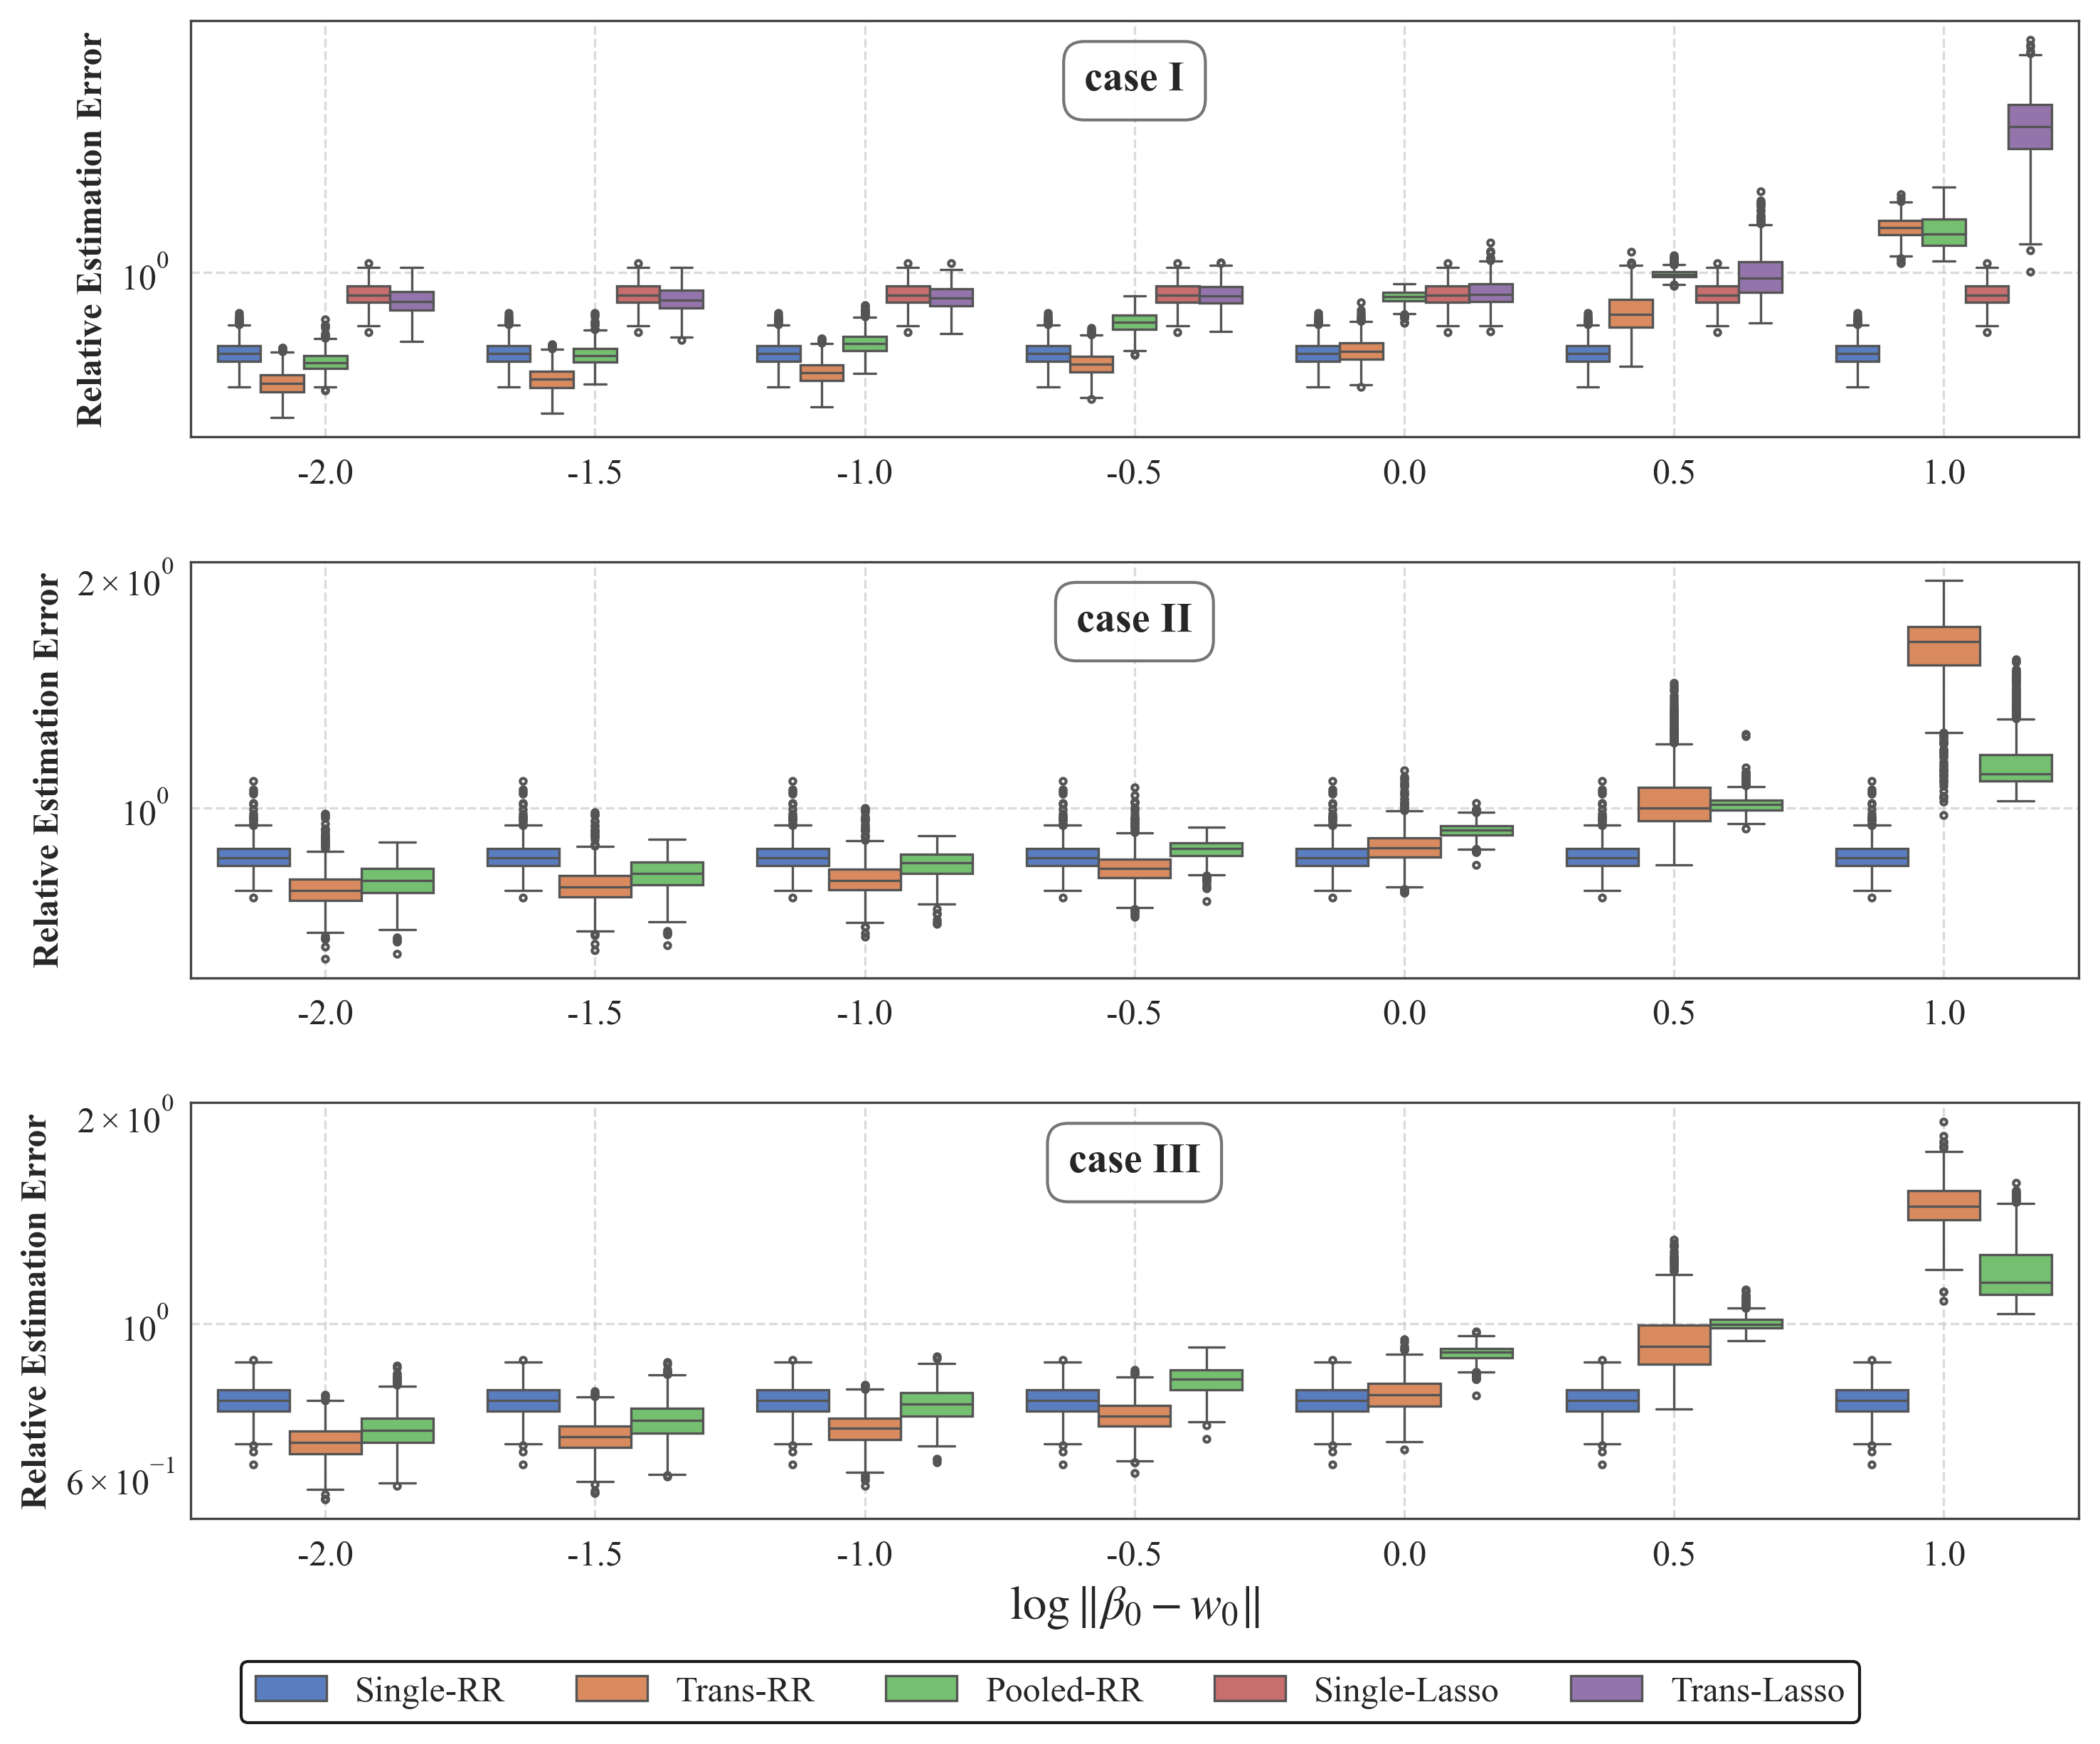

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 纯白色背景
bg_color = 'white'

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/1gaussian_cv_results_p400_simu1000.json',
    'res/1cauchy_cv_results_p400_simu1000.json',
    'res/1mix_cv_results_p400_simu1000.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

# 方法名称映射
method_mapping = {
    'Single RR': 'Single-RR',
    'Trans RR': 'Trans-RR',
    'Pooled RR': 'Pooled-RR',
    'Single Lasso': 'Single-Lasso',
    'Trans Lasso': 'Trans-Lasso'
}

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_mapping.get(method_name, method_name),  # 转换方法名称
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_mapping.get(method_name, method_name),  # 转换方法名称
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 设置子图背景色
    ax = axes[idx]
    ax.set_facecolor(bg_color)

    # 创建分组箱线图，使用log_dd作为x轴
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',  # 原始的配色方案
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签 - 字体大小为12
    ax.set_ylabel('Relative Estimation Error', fontsize=12, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度 - 水平显示
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=0)

    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 减小y轴刻度的文字大小
    ax.tick_params(axis='y', labelsize=12)

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.9, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 添加灰色虚线网格背景
    ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7)
    ax.set_axisbelow(True)  # 确保网格在数据下方

    # 调整边框和样式
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例，无标题
legend = fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.03),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=12)

# 为整个图形添加白色背景
fig.patch.set_facecolor('white')

# 保存图表
plt.savefig('res/methods_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)


# 显示图表
plt.show()

Horizontal line styled as grid added at y=2.0 with label for case I.
Figure saved as 'res/methods_comparison_styled_line.pdf'


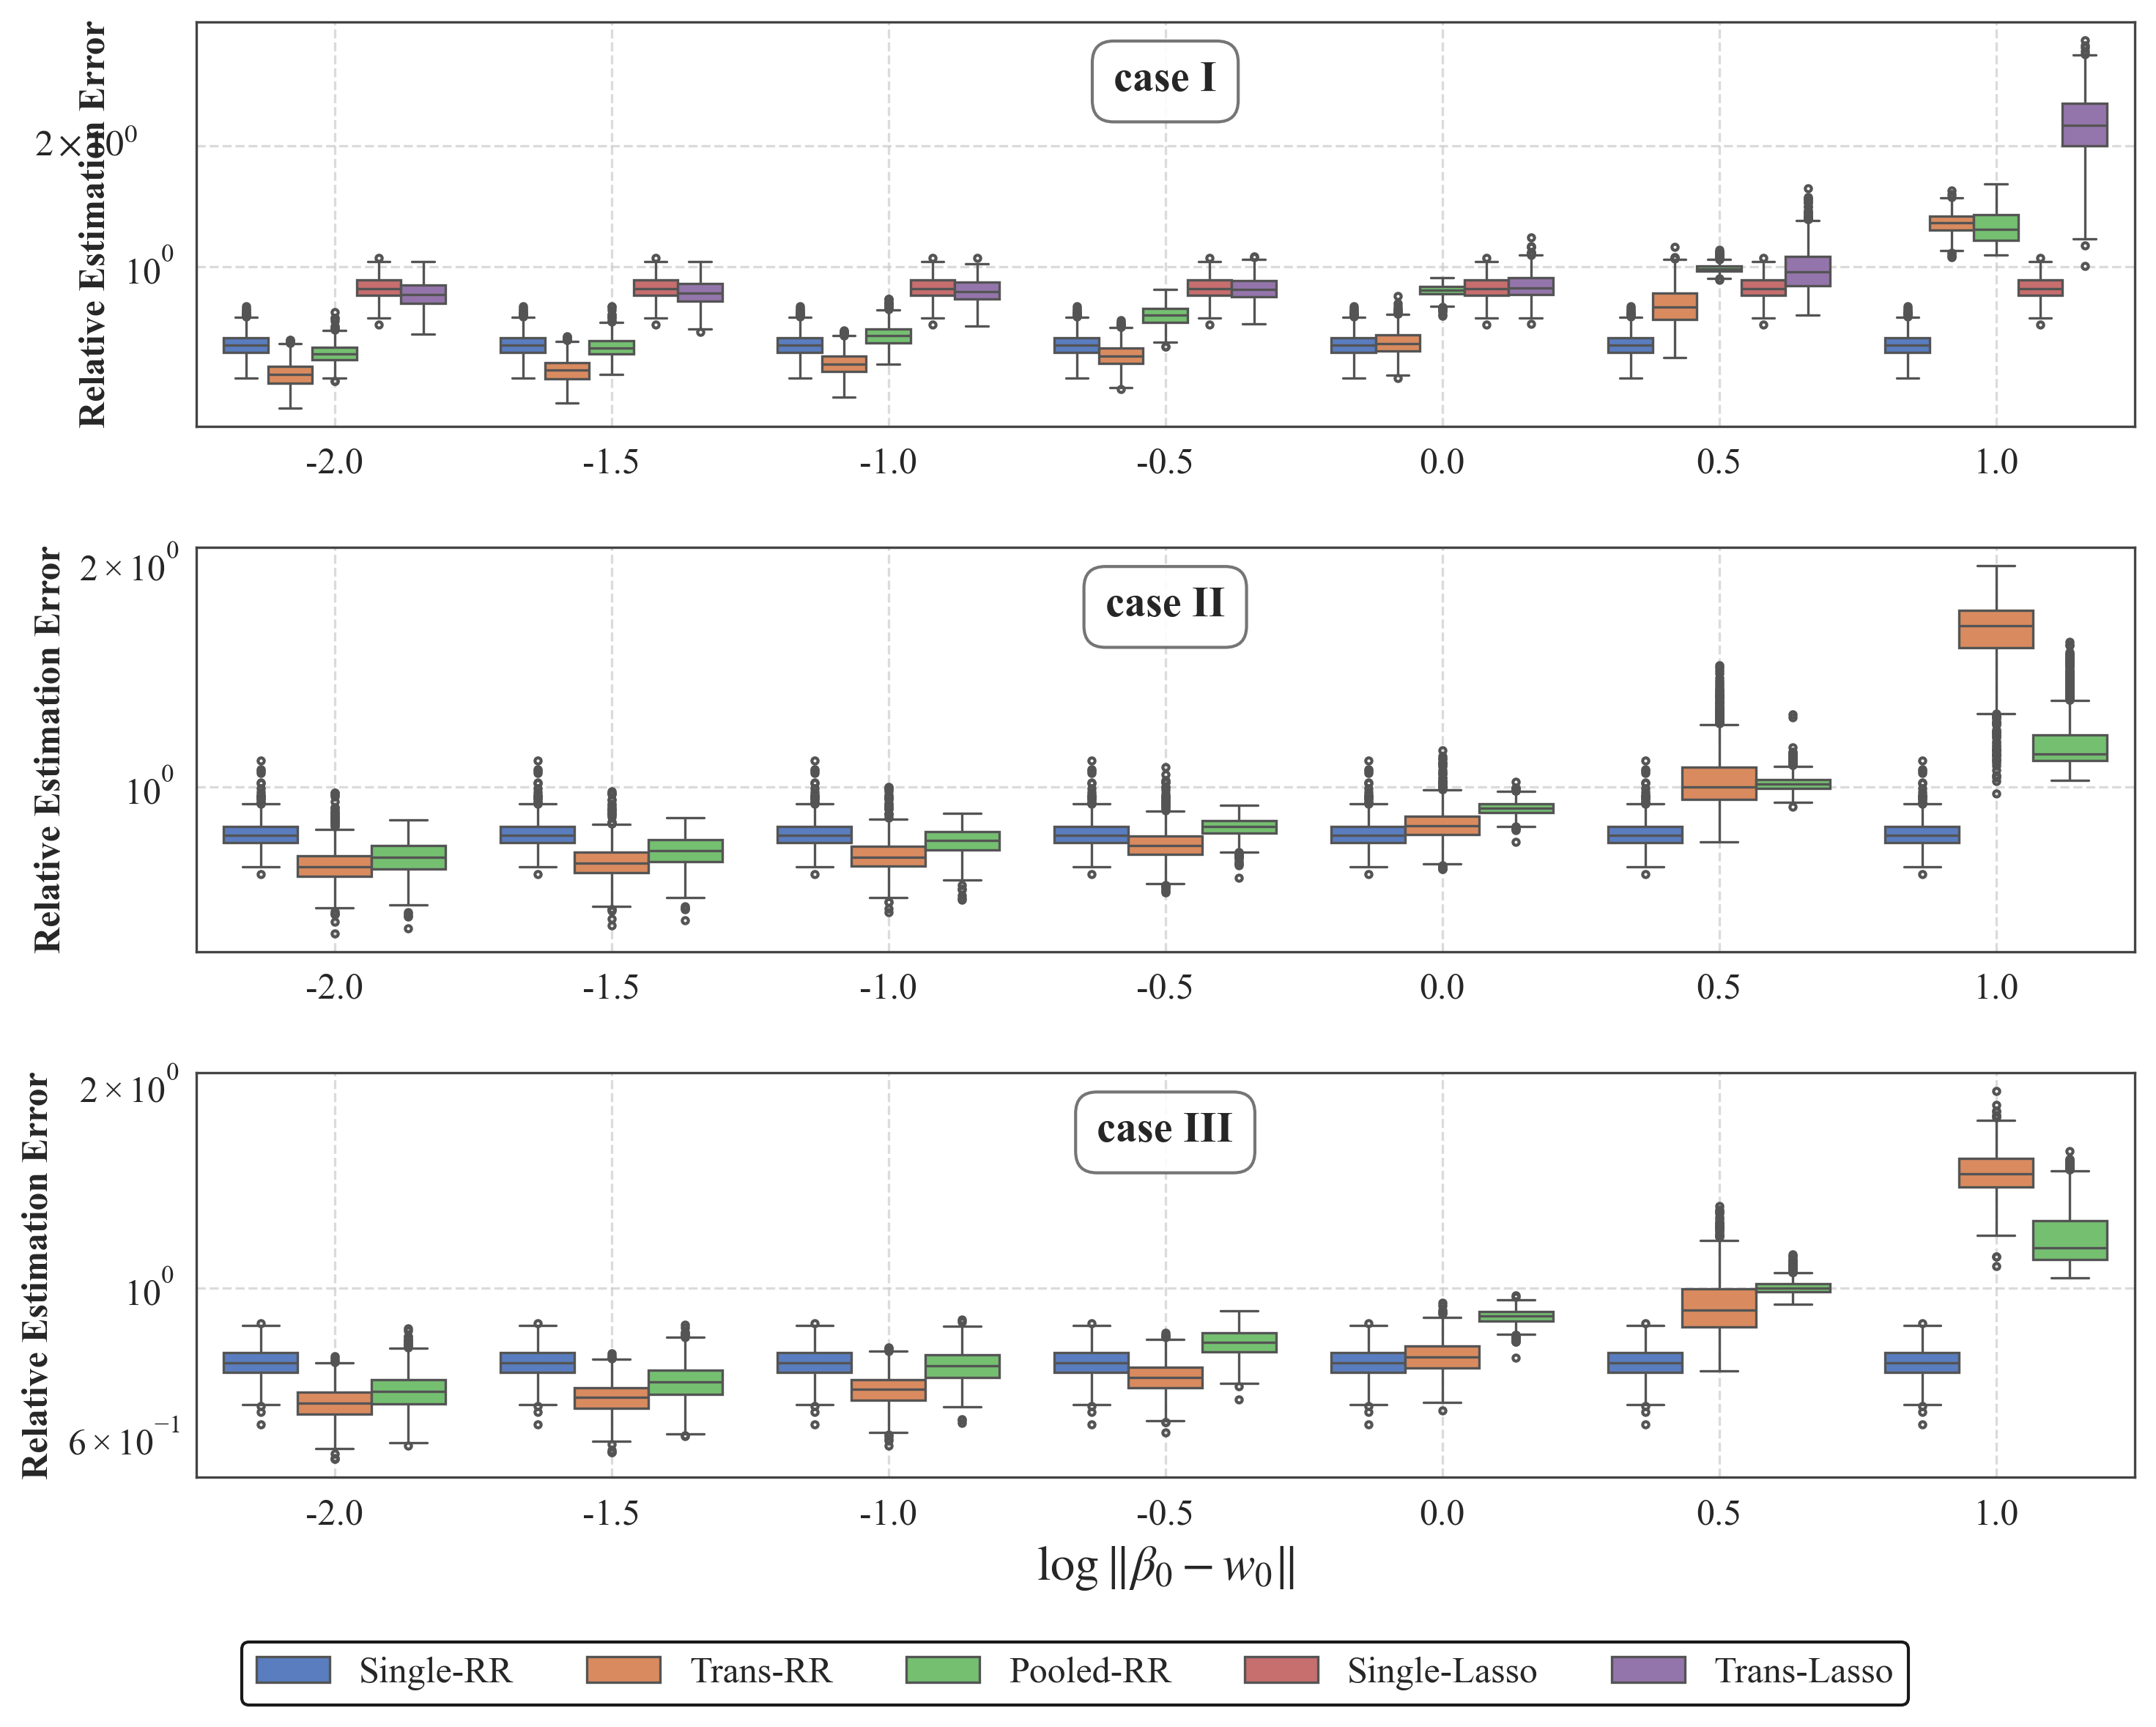

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})
# Get default y-tick label color for consistency
y_tick_label_color = plt.rcParams['ytick.color']


# 纯白色背景
bg_color = 'white'

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/1gaussian_cv_results_p400_simu1000.json',
    'res/1cauchy_cv_results_p400_simu1000.json',
    'res/1mix_cv_results_p400_simu1000.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

# 方法名称映射
method_mapping = {
    'Single RR': 'Single-RR',
    'Trans RR': 'Trans-RR',
    'Pooled RR': 'Pooled-RR',
    'Single Lasso': 'Single-Lasso',
    'Trans Lasso': 'Trans-Lasso'
}

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    try:
        with open(file_path, 'r') as f:
            data = json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found - {file_path}. Skipping this subplot.")
        ax = axes[idx]
        ax.text(0.5, 0.5, f"Data not found:\n{file_path}",
                horizontalalignment='center', verticalalignment='center',
                transform=ax.transAxes, color='red', fontsize=10)
        dist_name_map = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
        title_text = dist_name_map.get(dist_type, f"Subplot {idx+1}")
        ax.text(0.5, 0.9, title_text,
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')
        ax.set_title("")
        if idx == 2:
            ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
        else:
            ax.set_xlabel('')
        ax.set_ylabel('Relative Estimation Error', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7, zorder=1.0) # Grid zorder
        ax.set_axisbelow(True)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
            spine.set_edgecolor('#444444')
        ax.tick_params(width=0.8)
        current_legend = ax.get_legend()
        if current_legend:
            current_legend.remove()
        continue

    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(dd_val)

        results_dict = data[dd_val_str]['results_df']

        is_index_based = any(key.isdigit() for key in results_dict.keys()) and \
                         isinstance(list(results_dict.values())[0], dict) if results_dict else False

        if is_index_based:
            for sim_idx_results in results_dict.values():
                for method_name, errors_dict in sim_idx_results.items():
                    for error_val in errors_dict.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_mapping.get(method_name, method_name),
                            'error': error_val
                        })
        else:
            for method_name, errors_dict in results_dict.items():
                for error_val in errors_dict.values():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_mapping.get(method_name, method_name),
                        'error': error_val
                    })

    plot_data = pd.DataFrame(all_data)

    ax = axes[idx]
    ax.set_facecolor(bg_color)

    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    ax.set_ylabel('Relative Estimation Error', fontsize=12, fontweight='bold')

    if idx == 2:
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')

    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    xtick_labels_str = [f"{val:.1f}" for val in log_dd_values_sorted]
    ax.set_xticklabels(xtick_labels_str, rotation=0)

    ax.set_yscale('log')
    ax.tick_params(axis='y', labelsize=12) # y-tick label size set here

    # --- MODIFICATION START: Add horizontal line y=2 (styled as grid) for case I ---
    if idx == 0:  # case I (Gaussian)
        y_value_to_mark = 2.0  # This is 2 * 10^0

        # Line styled like the background grid
        ax.axhline(y=y_value_to_mark,
                   color='#CCCCCC',      # Same color as grid
                   linestyle='--',       # Same linestyle as grid
                   linewidth=0.8,        # Same linewidth as grid
                   alpha=0.7,            # Same alpha as grid
                   zorder=1.0)           # zorder similar to grid (grid is often 1.0)

        # Add text annotation on the left, styled like y-axis tick labels
        # Using a raw string r'...' for LaTeX
        label_text = r'$2 \times 10^0$'
        ax.text(x=-0.03,  # x-position in axes fraction (left of y-axis spine)
                y=y_value_to_mark,
                s=label_text,
                transform=ax.get_yaxis_transform(), # x in axes coords, y in data coords
                ha='right',  # Horizontal alignment
                va='center', # Vertical alignment
                fontsize=12, # Same fontsize as y-tick labels
                color=y_tick_label_color # Same color as y-tick labels
               )
        print(f"Horizontal line styled as grid added at y={y_value_to_mark} with label for case I.")
    # --- MODIFICATION END ---

    dist_name_map = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.9, f"{dist_name_map[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    ax.set_title("")
    ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7, zorder=1.0) # Ensure grid zorder is low
    ax.set_axisbelow(True) # Ensures data artists are drawn above the grid

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    if legend_handles is None and ax.get_legend_handles_labels()[0]:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    current_legend = ax.get_legend()
    if current_legend:
        current_legend.remove()

plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.15, left=0.1) # Adjusted left margin slightly for the new label

if legend_handles and legend_labels:
    fig.legend(legend_handles, legend_labels,
              loc='lower center',
              bbox_to_anchor=(0.5, 0.01),
              ncol=len(legend_labels),
              frameon=True,
              framealpha=0.9,
              edgecolor='black',
              fancybox=True,
              fontsize=12)
else:
    print("Warning: Could not generate figure legend (no data or handles found).")

fig.patch.set_facecolor('white')

try:
    plt.savefig('res/methods_comparison_styled_line.pdf', format='pdf', bbox_inches='tight', dpi=300)
    print("Figure saved as 'res/methods_comparison_styled_line.pdf'")
except FileNotFoundError:
    print("Error: 'res' directory does not exist or path is invalid. Could not save figure.")
except Exception as e:
    print(f"An error occurred while saving the figure: {e}")

plt.show()

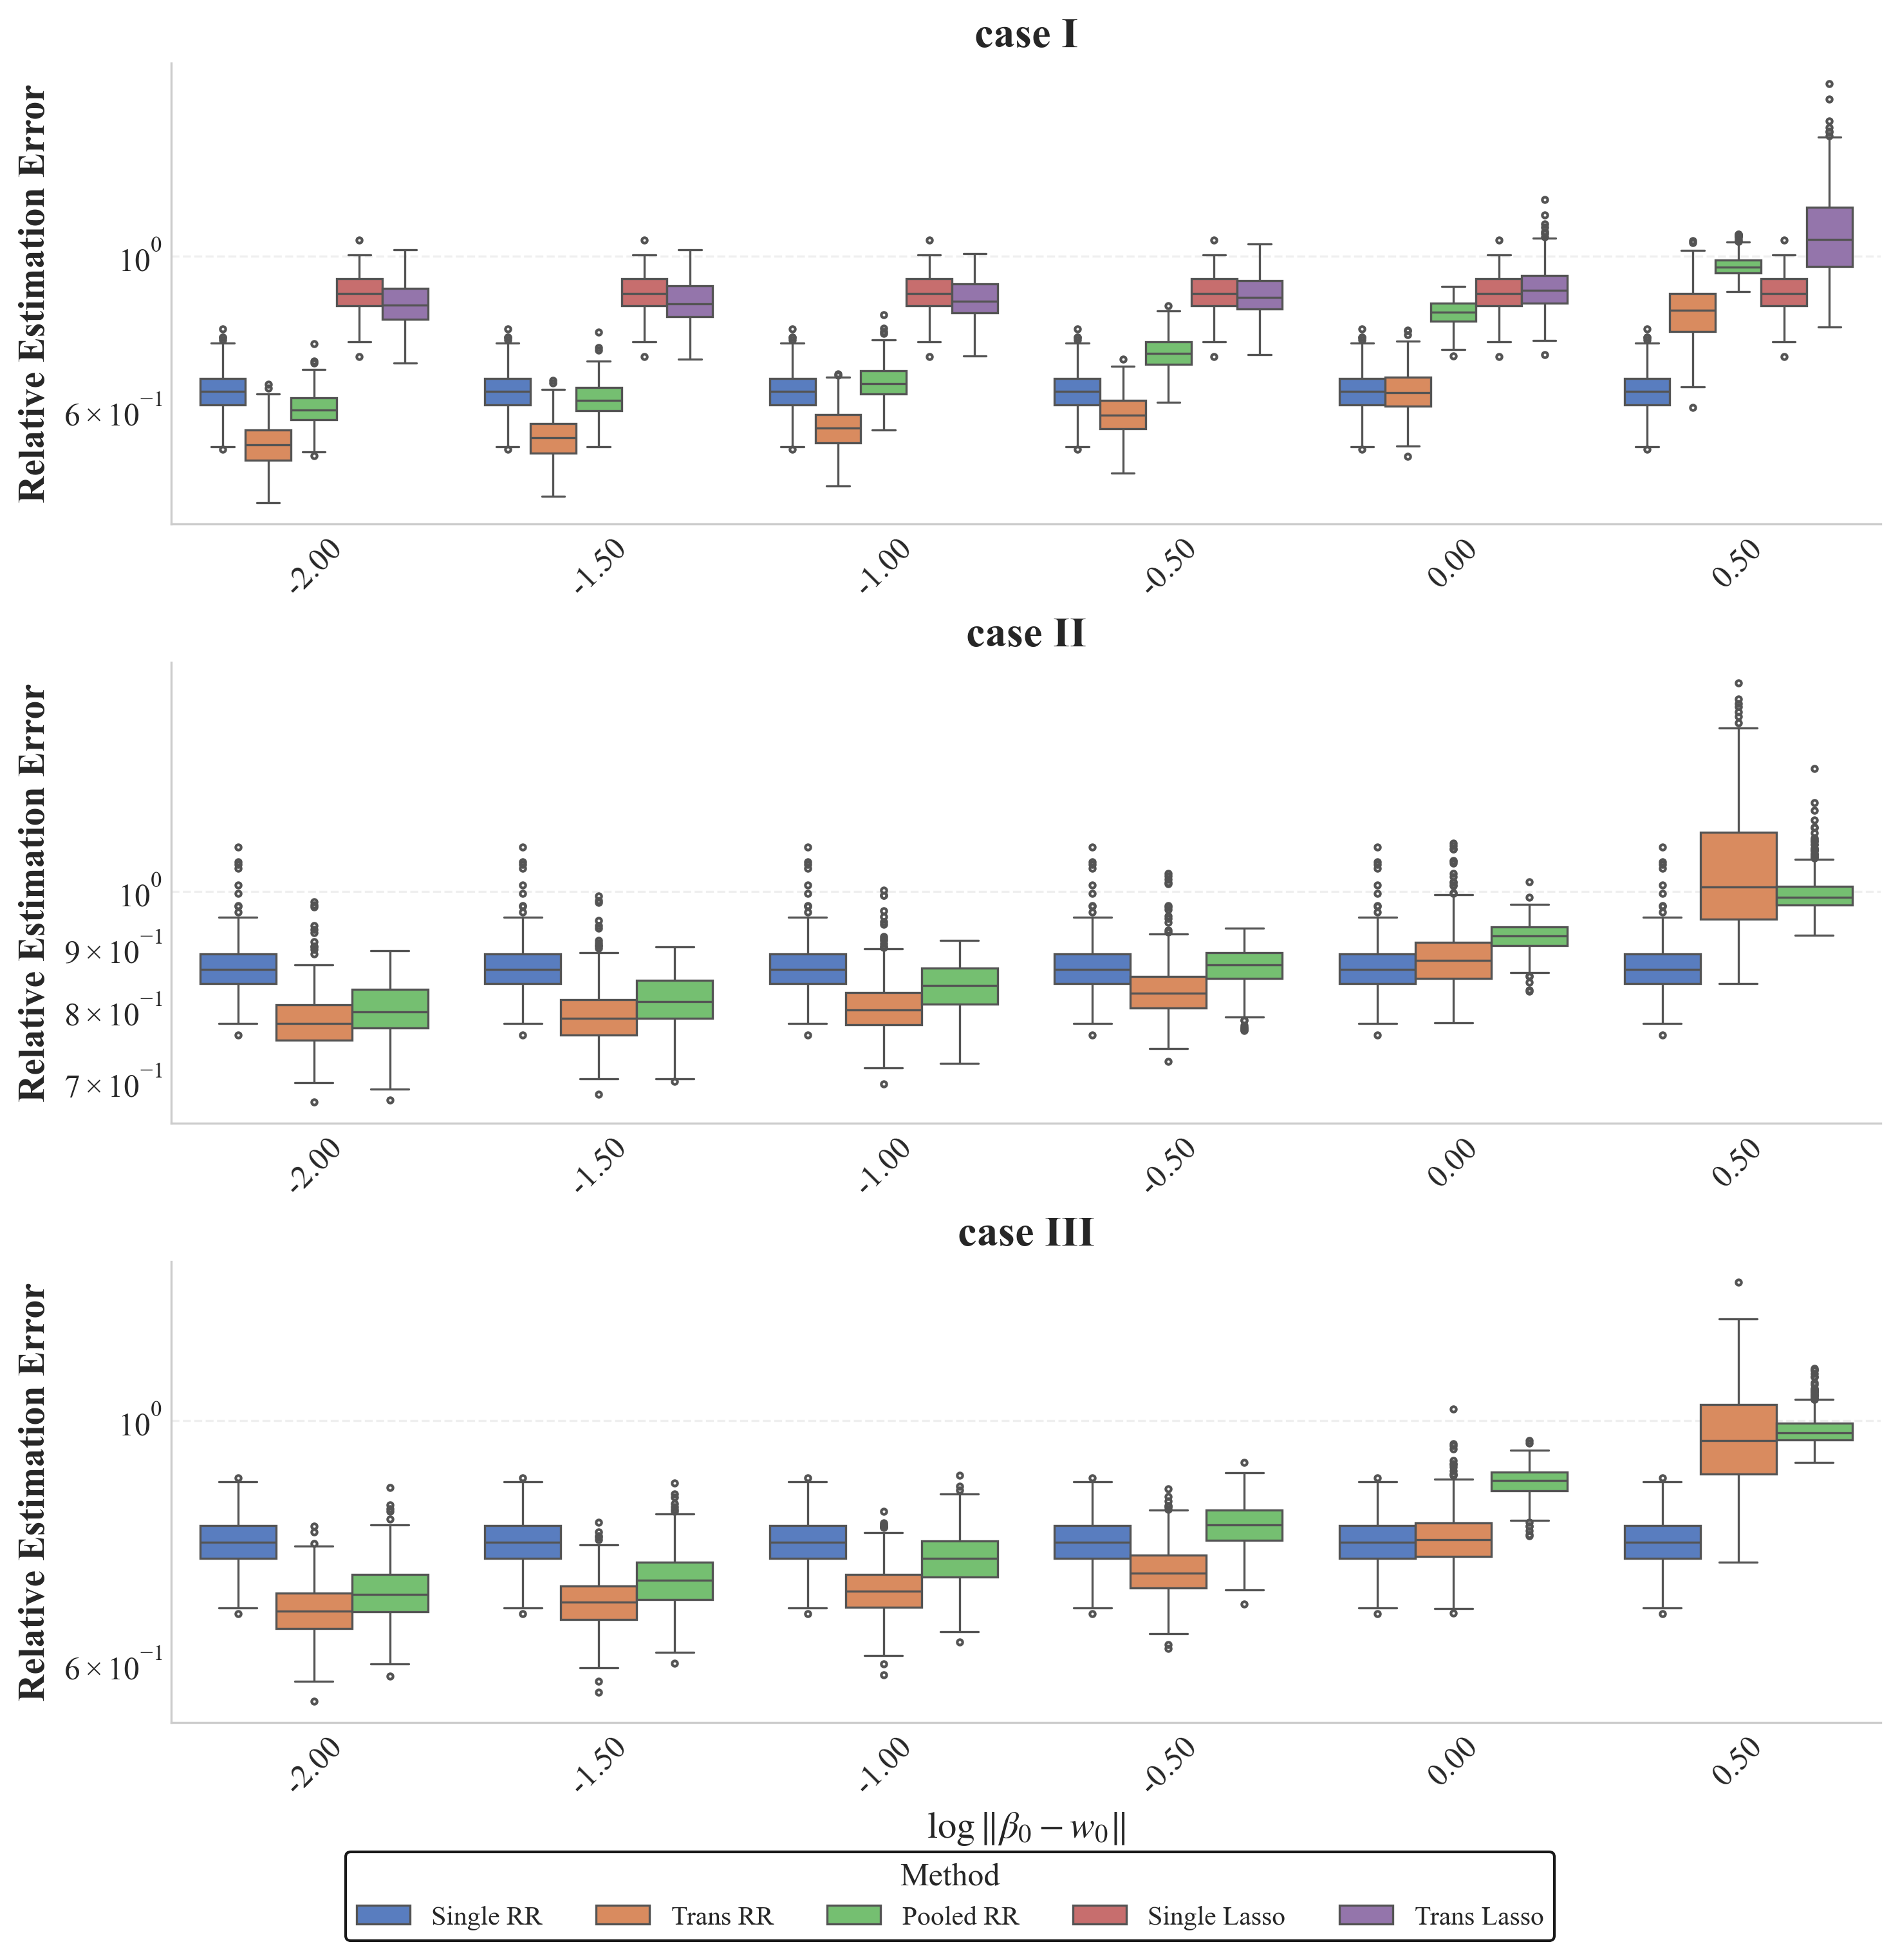

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_name,
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_name,
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 创建分组箱线图，使用log_dd作为x轴
    ax = axes[idx]
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签
    ax.set_ylabel('Relative Estimation Error', fontsize=14, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=14, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.2f}" for val in log_dd_values_sorted], rotation=45)
    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 添加分布类型标题
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.set_title(f"{dist_name[dist_type]}", fontsize=16, fontweight='bold')

    # 网格线
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')

    # 调整刻度和边框
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例
fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.02),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=10,
          title='Method')

# 保存图表
plt.savefig('three_distributions_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 显示图表
plt.show()

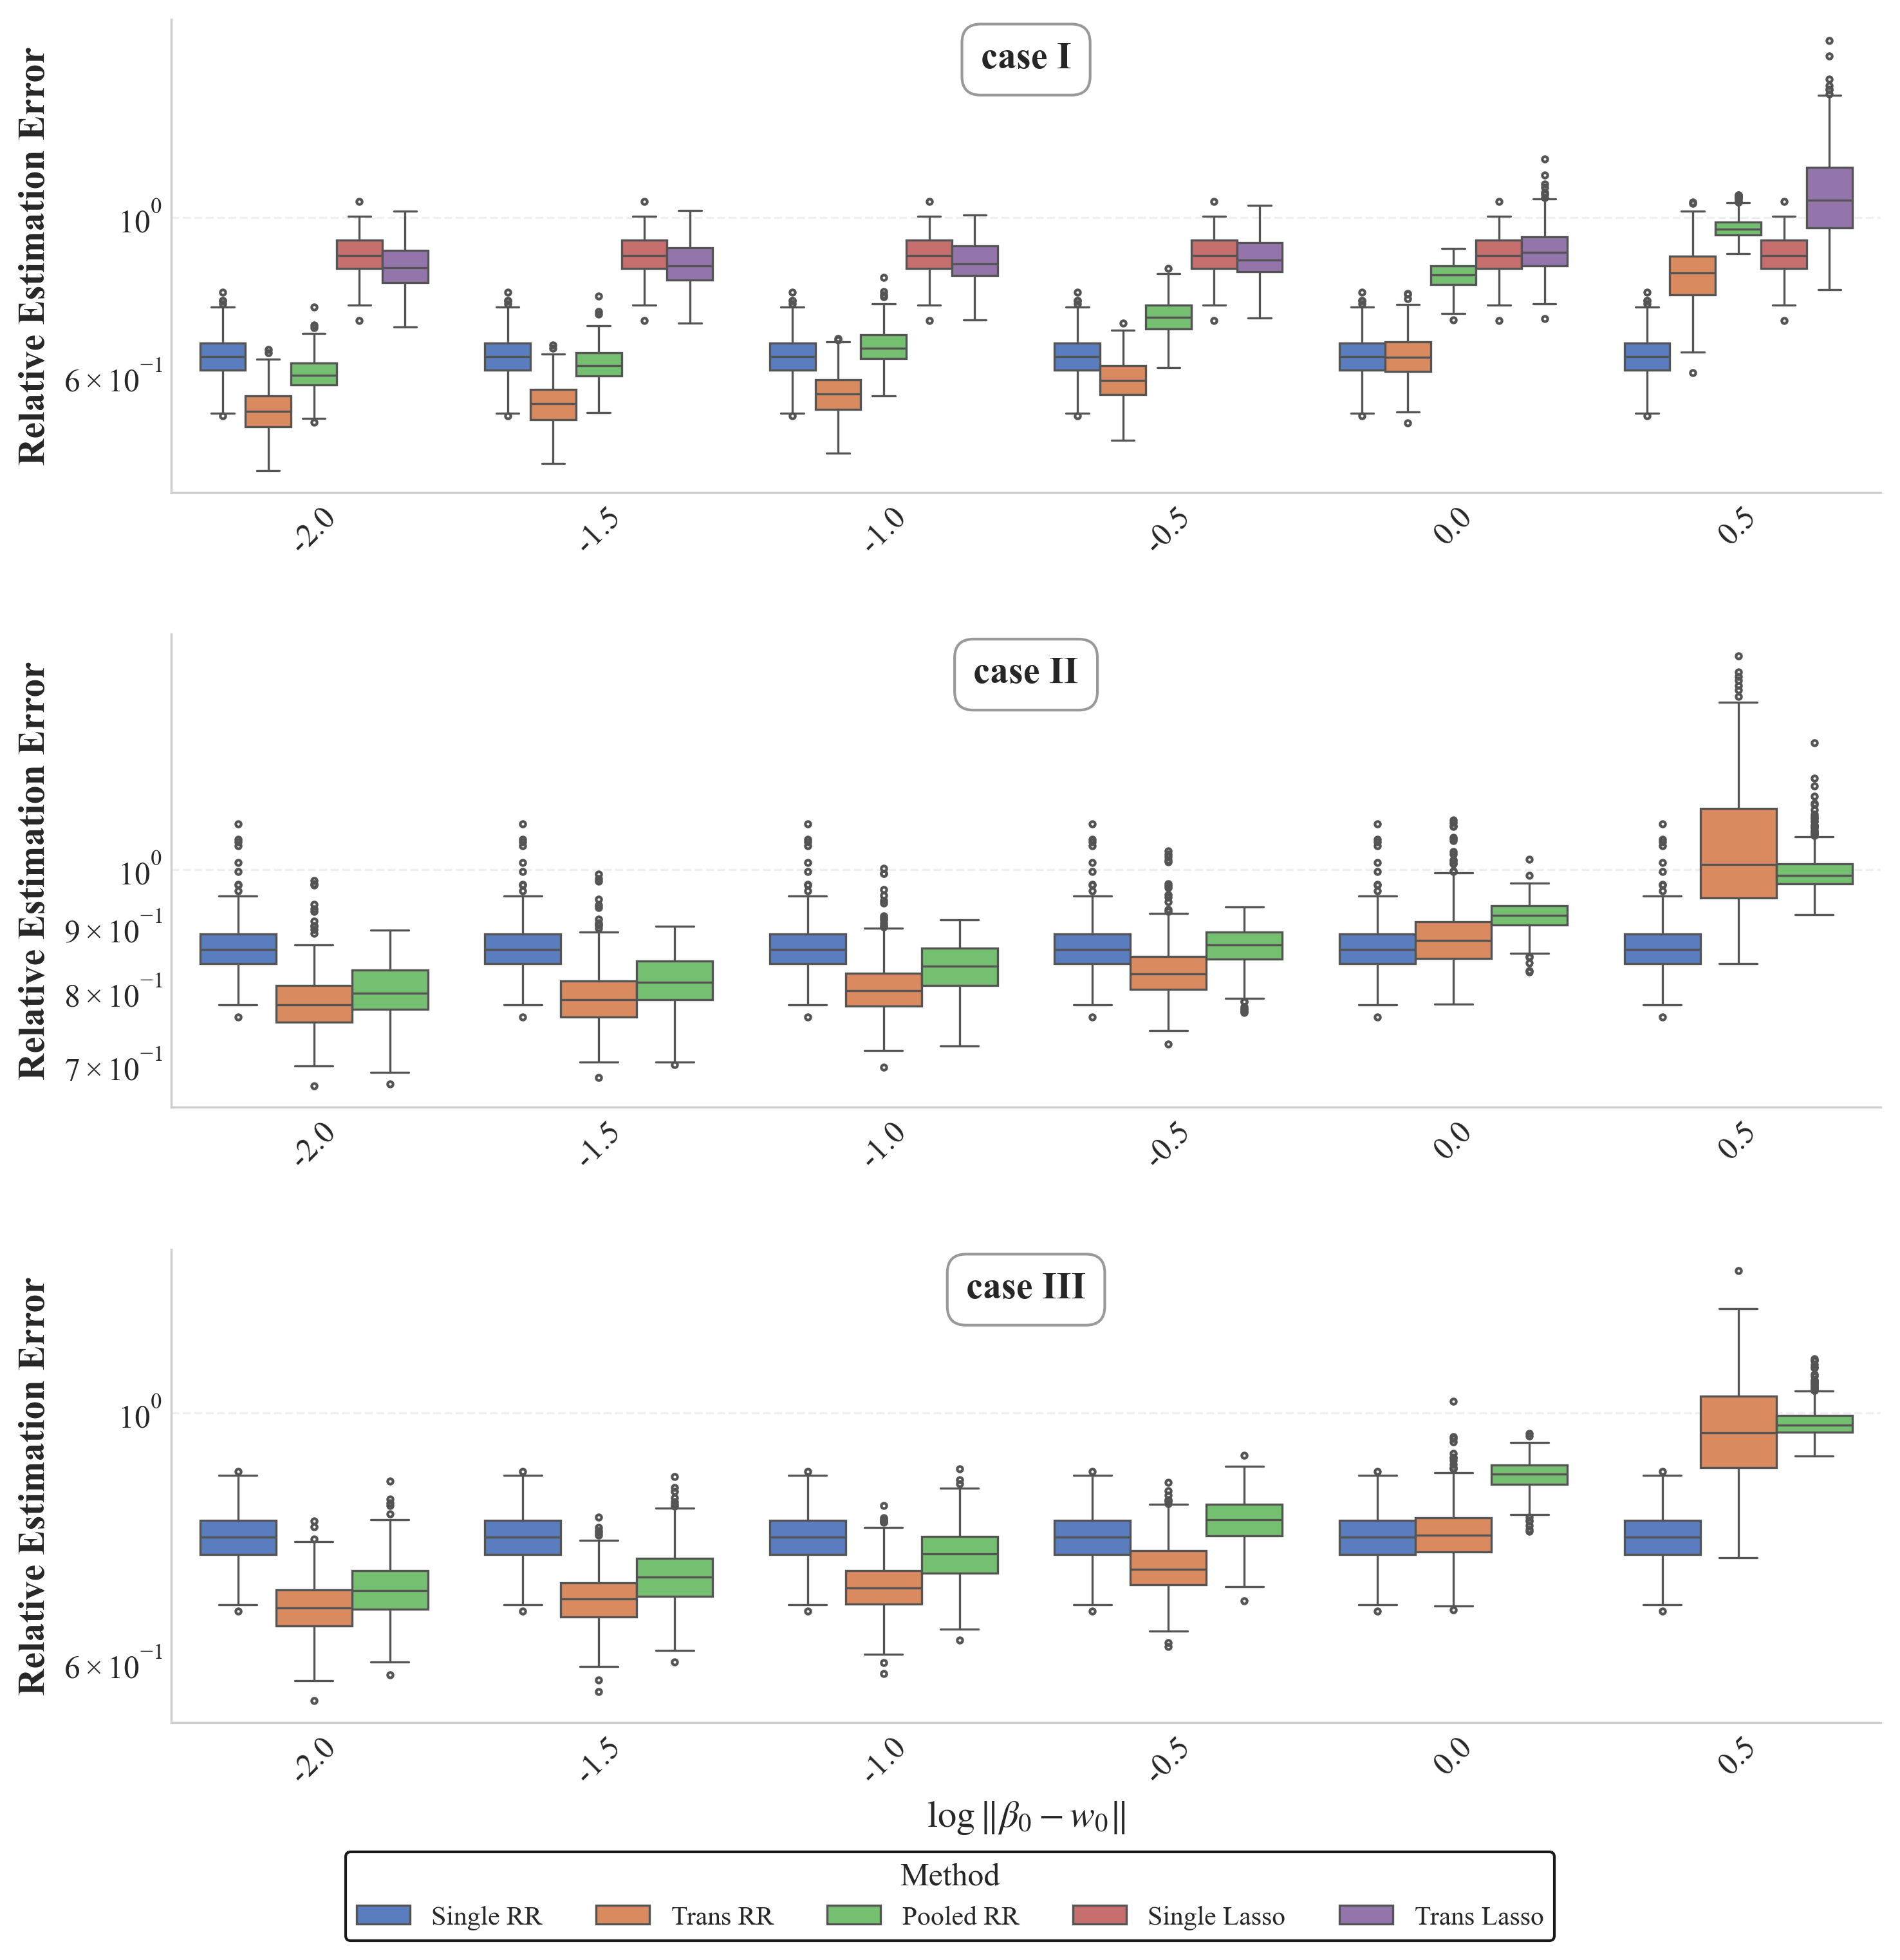

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_name,
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_name,
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 创建分组箱线图，使用log_dd作为x轴
    ax = axes[idx]
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签
    ax.set_ylabel('Relative Estimation Error', fontsize=14, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=14, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=45)
    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.95, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 网格线
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')

    # 调整刻度和边框
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例
fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.02),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=10,
          title='Method')

# 保存图表
plt.savefig('three_distributions_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 显示图表
plt.show()

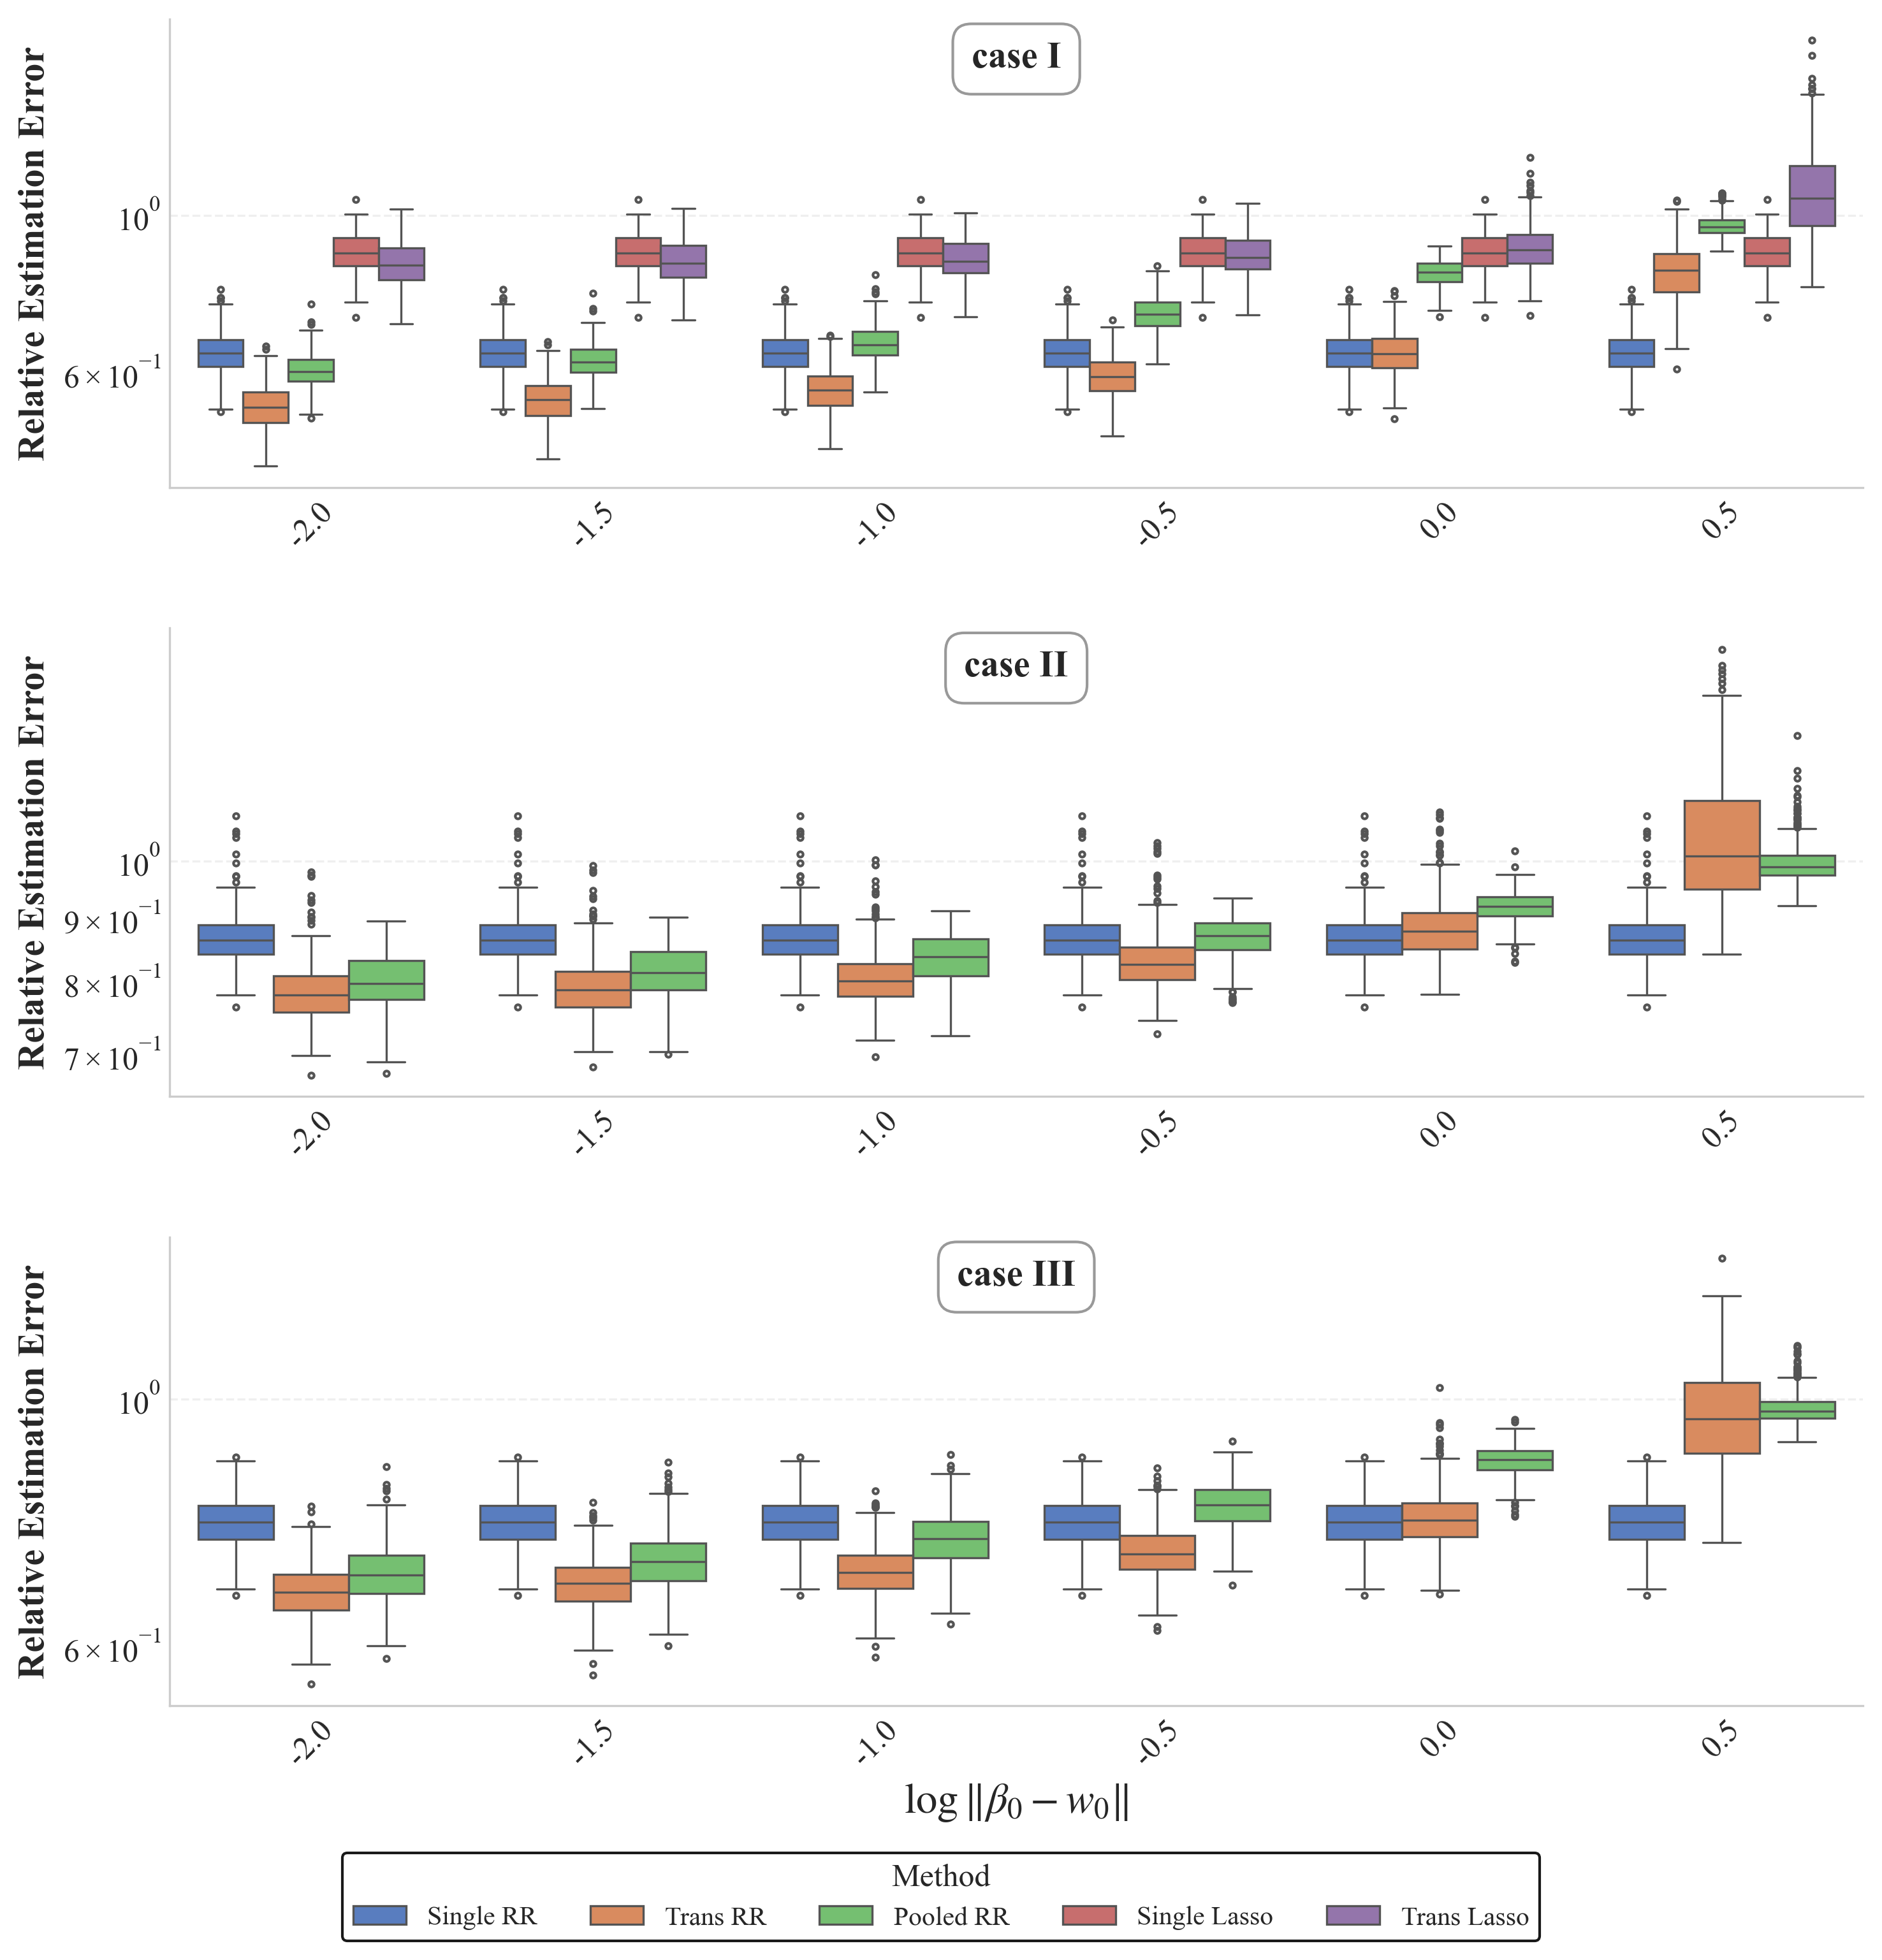

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_name,
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_name,
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 创建分组箱线图，使用log_dd作为x轴
    ax = axes[idx]
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签
    ax.set_ylabel('Relative Estimation Error', fontsize=14, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=45)
    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.95, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 网格线
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')

    # 调整刻度和边框
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例
fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.03),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=10,
          title='Method')

# 保存图表
plt.savefig('three_distributions_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 显示图表
plt.show()

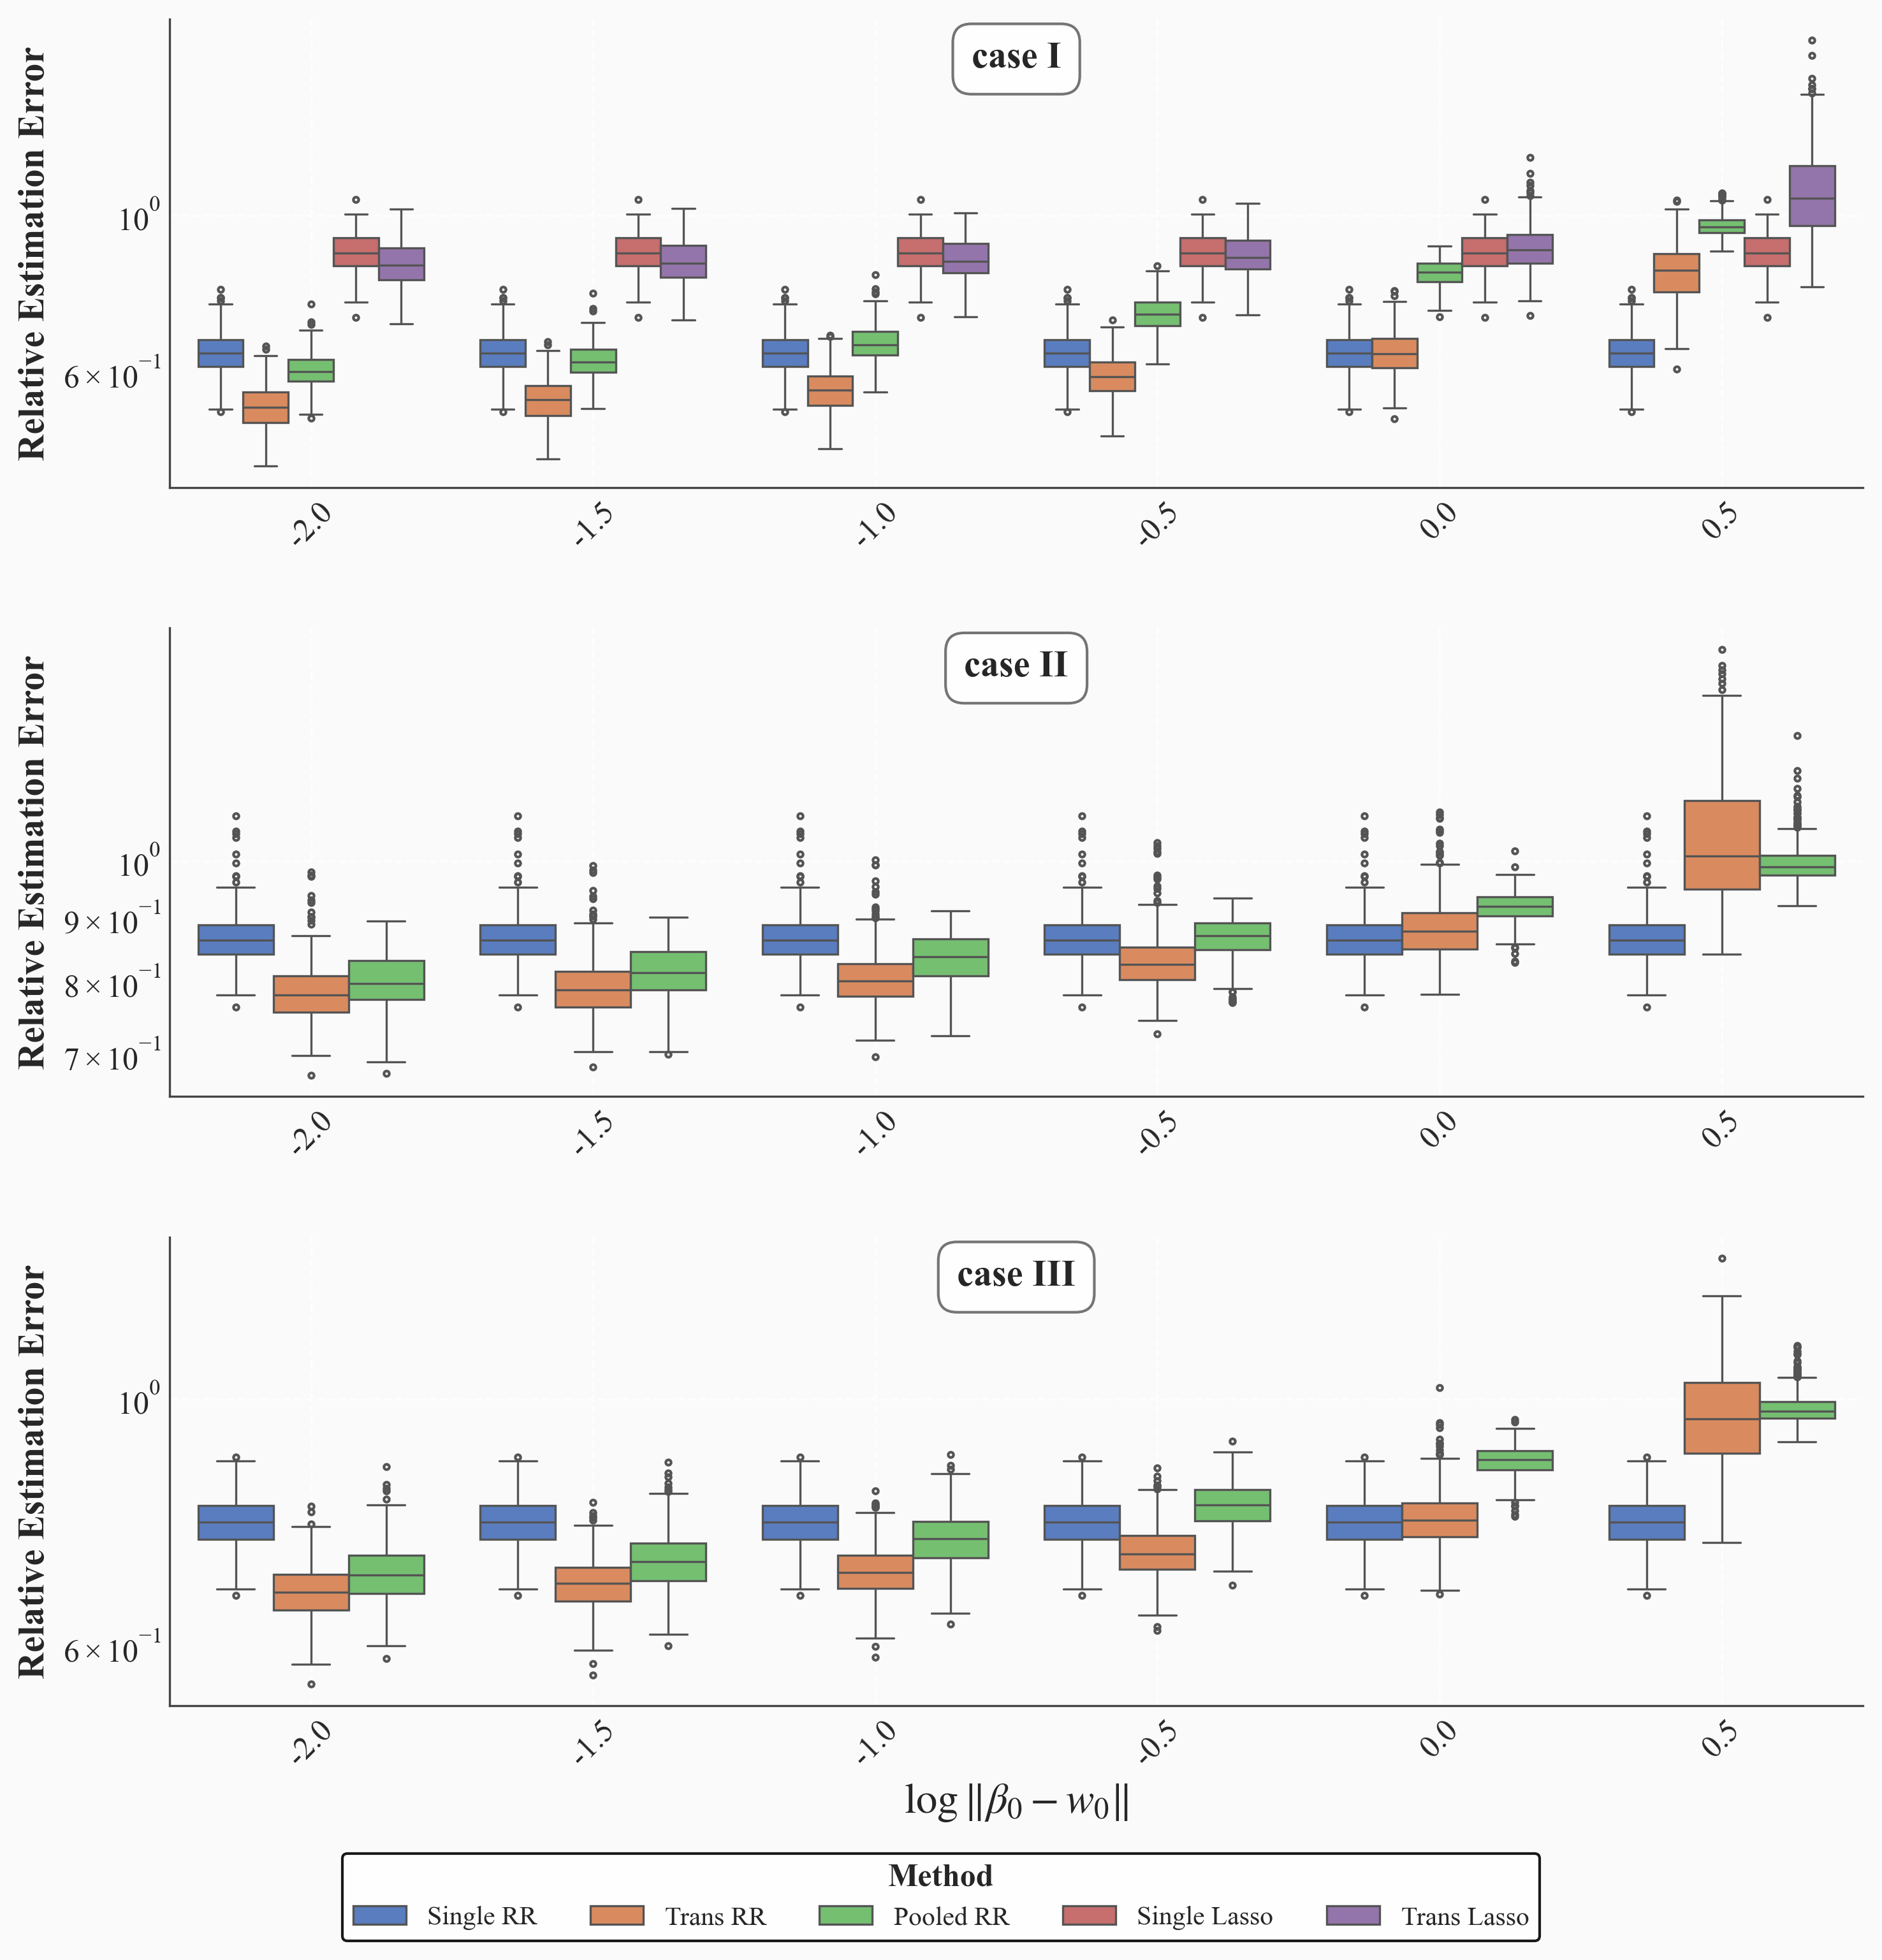

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 浅色背景，但更接近白色
bg_color = '#FAFAFA'  # 非常浅的灰色，接近白色

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 10), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_name,
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_name,
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 设置子图背景色
    ax = axes[idx]
    ax.set_facecolor(bg_color)

    # 创建分组箱线图，使用log_dd作为x轴
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',  # 恢复原来的配色方案
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签
    ax.set_ylabel('Relative Estimation Error', fontsize=14, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=45)

    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.95, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 添加白色虚线网格背景
    ax.grid(True, linestyle='--', linewidth=0.8, color='white', alpha=0.9)
    ax.set_axisbelow(True)  # 确保网格在数据下方

    # 调整边框和样式
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例
legend = fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.03),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=10,
          title='Method')

legend.get_title().set_fontweight('bold')

# 为整个图形添加背景
fig.patch.set_facecolor('#FAFAFA')

# 保存图表
plt.savefig('three_distributions_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.savefig('three_distributions_comparison.png', format='png', bbox_inches='tight', dpi=300)

# 显示图表
plt.show()

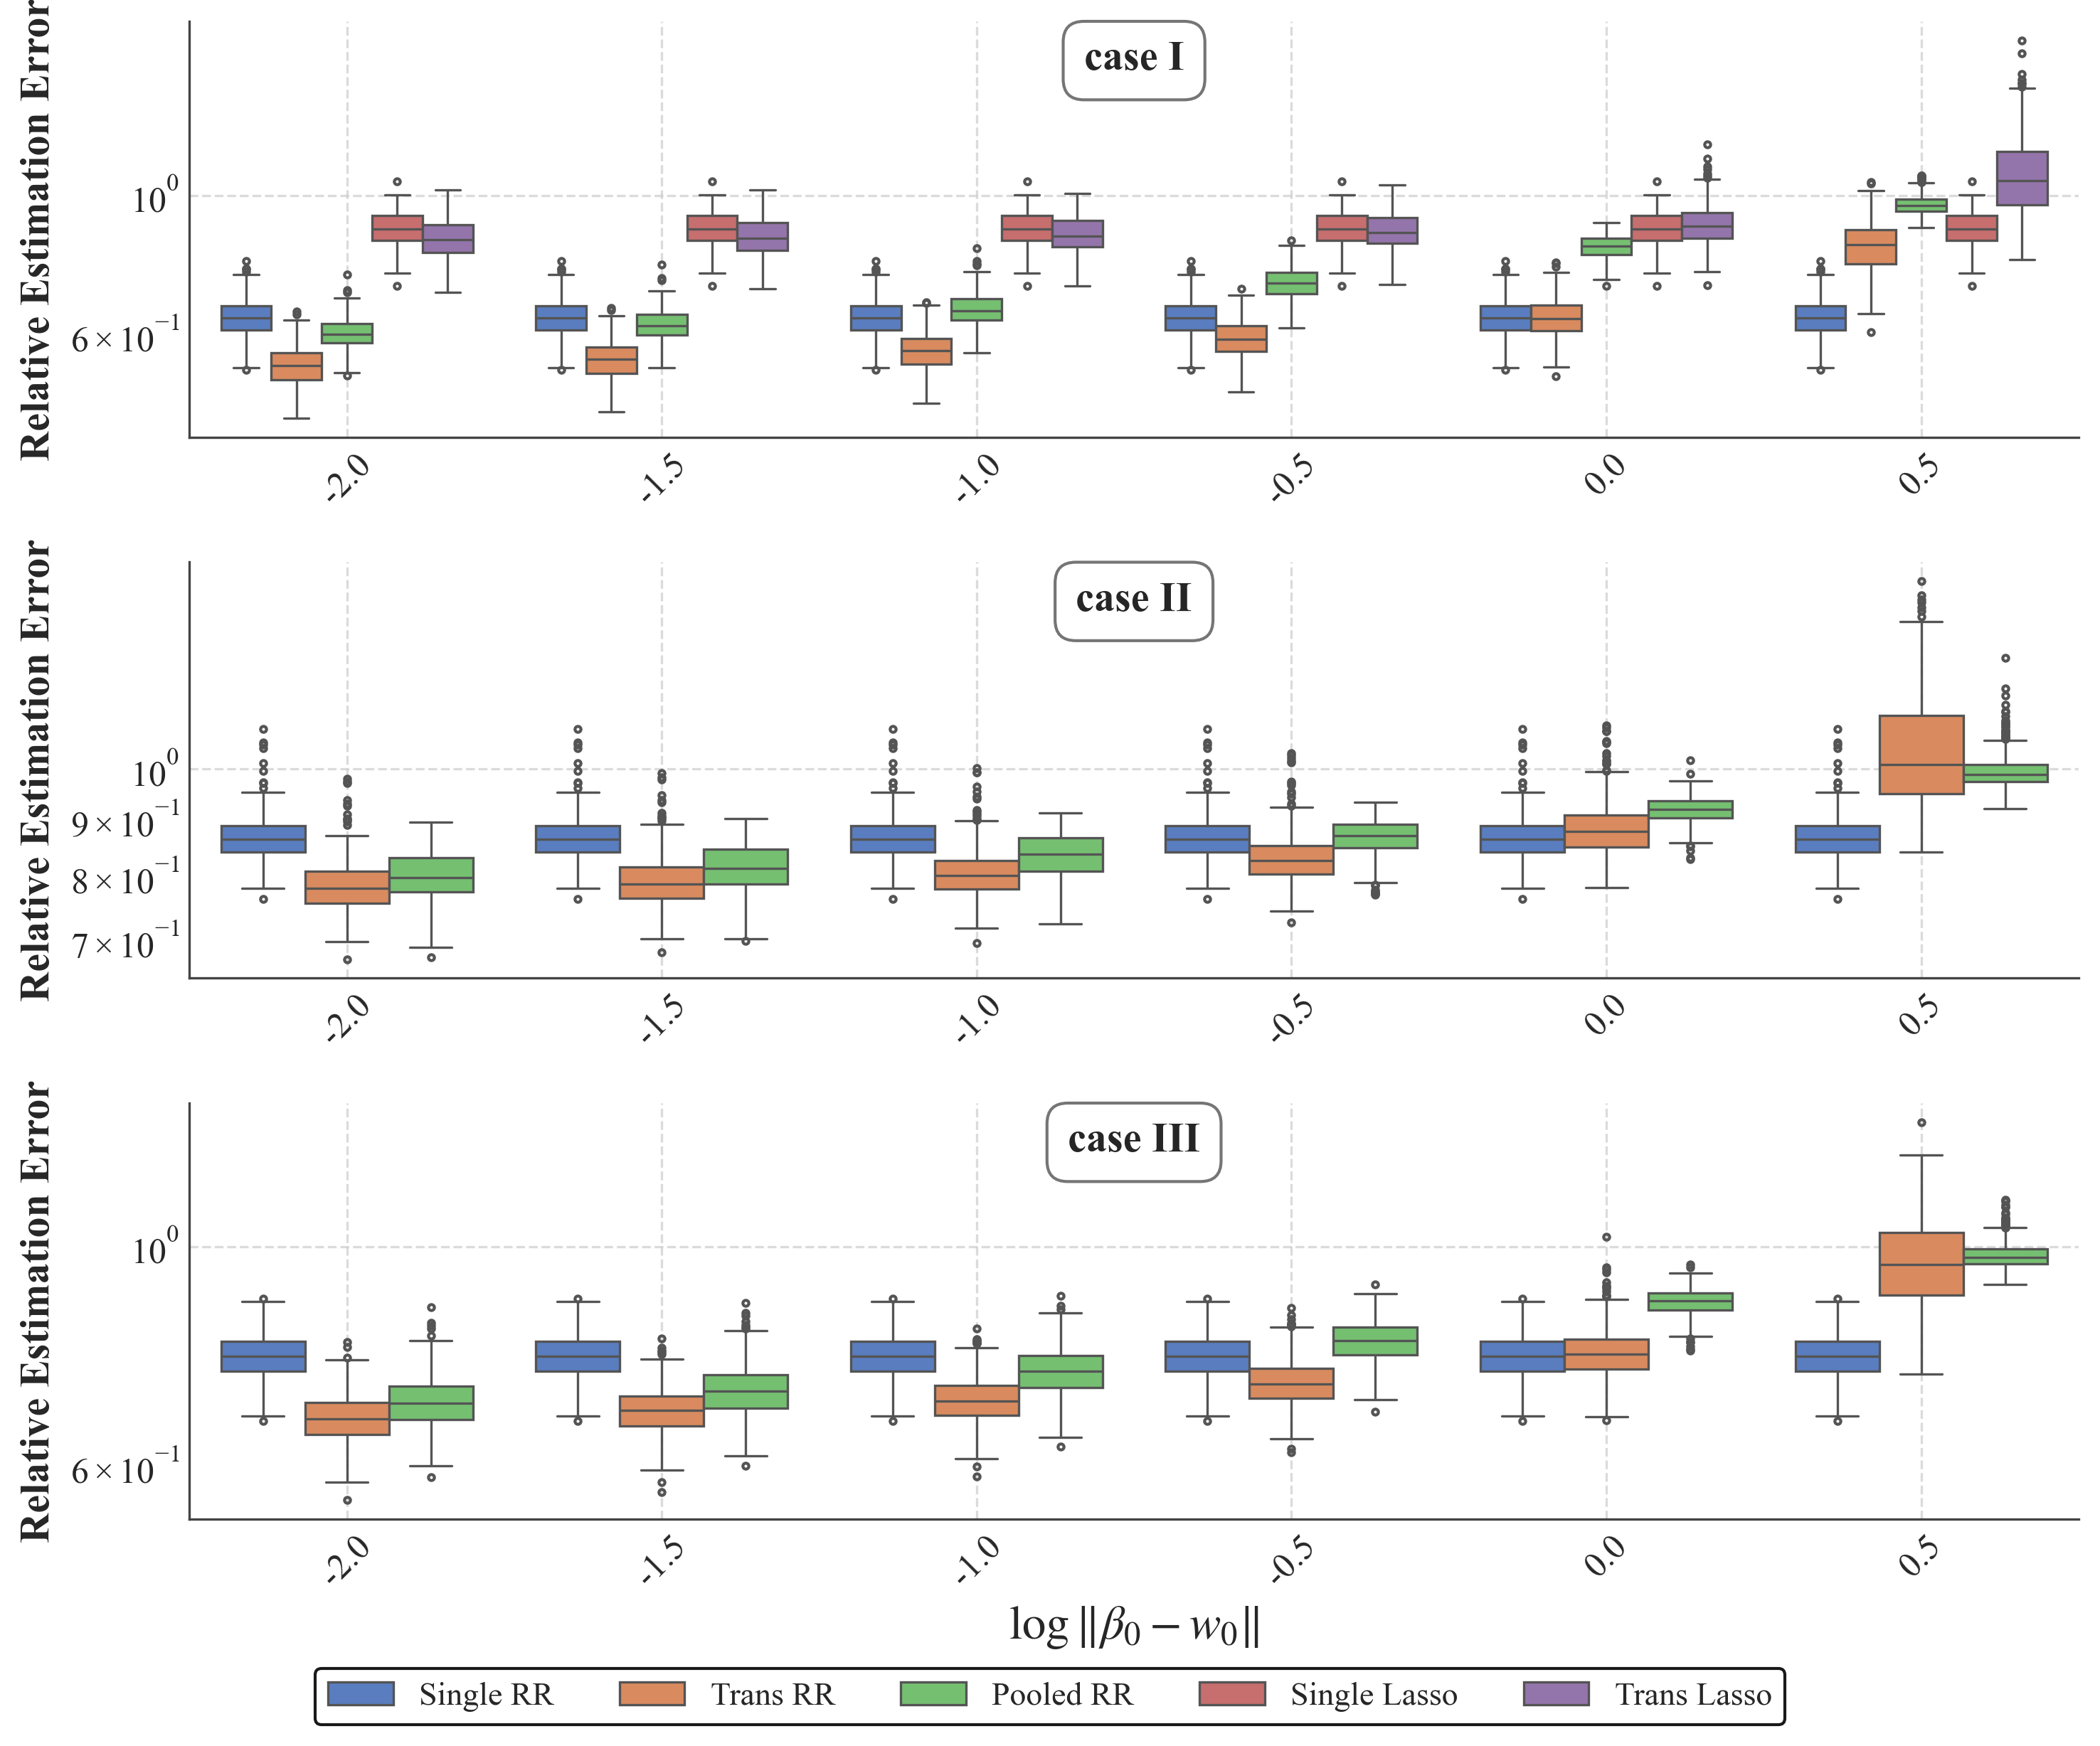

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 纯白色背景
bg_color = 'white'

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_name,
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_name,
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 设置子图背景色
    ax = axes[idx]
    ax.set_facecolor(bg_color)

    # 创建分组箱线图，使用log_dd作为x轴
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',  # 原始的配色方案
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签
    ax.set_ylabel('Relative Estimation Error', fontsize=14, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=45)

    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.95, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 添加灰色虚线网格背景
    ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7)
    ax.set_axisbelow(True)  # 确保网格在数据下方

    # 调整边框和样式
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例，无标题
legend = fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.03),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=11)

# 为整个图形添加白色背景
fig.patch.set_facecolor('white')

# 保存图表
plt.savefig('three_distributions_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)
plt.savefig('three_distributions_comparison.png', format='png', bbox_inches='tight', dpi=300)

# 显示图表
plt.show()

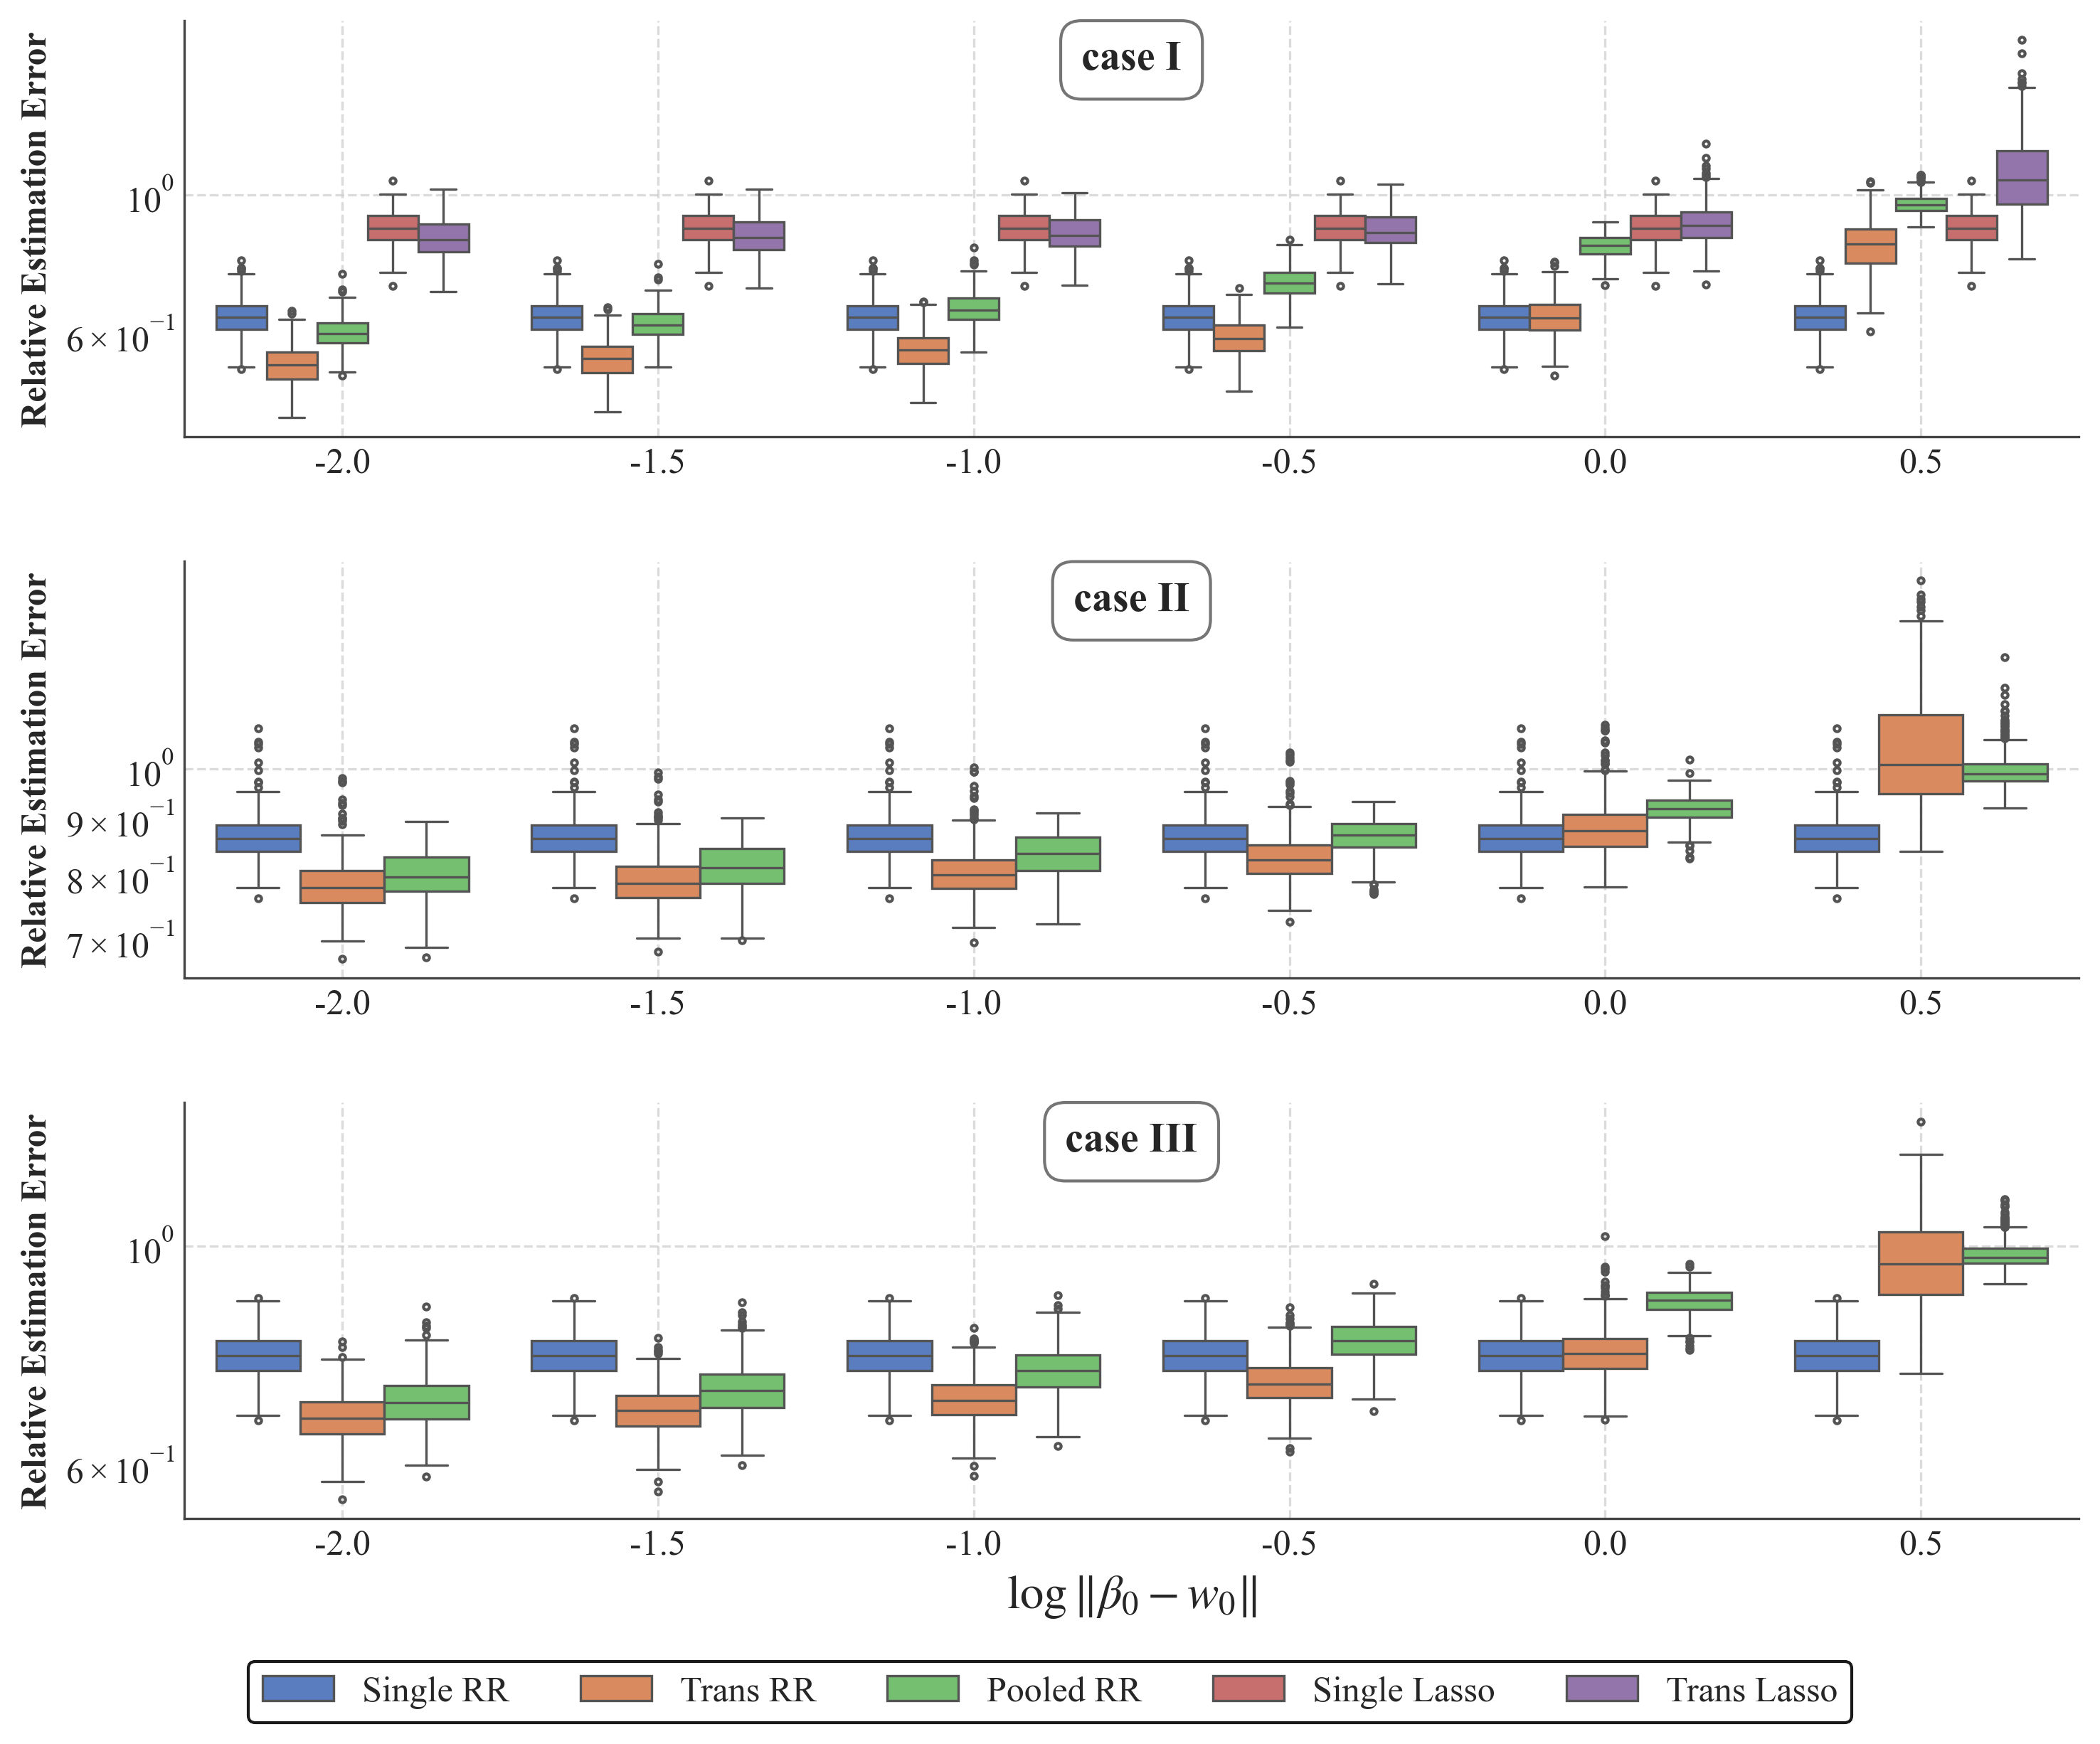

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 纯白色背景
bg_color = 'white'

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_name,
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_name,
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 设置子图背景色
    ax = axes[idx]
    ax.set_facecolor(bg_color)

    # 创建分组箱线图，使用log_dd作为x轴
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',  # 原始的配色方案
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签 - 字体大小从14减小到12
    ax.set_ylabel('Relative Estimation Error', fontsize=12, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度 - 不再旋转标签
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=0)

    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 减小y轴刻度的文字大小
    ax.tick_params(axis='y', labelsize=12)

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.95, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 添加灰色虚线网格背景
    ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7)
    ax.set_axisbelow(True)  # 确保网格在数据下方

    # 调整边框和样式
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例，无标题
legend = fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.03),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=12)

# 为整个图形添加白色背景
fig.patch.set_facecolor('white')

# 保存图表
plt.savefig('res/three_distributions_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)


# 显示图表
plt.show()

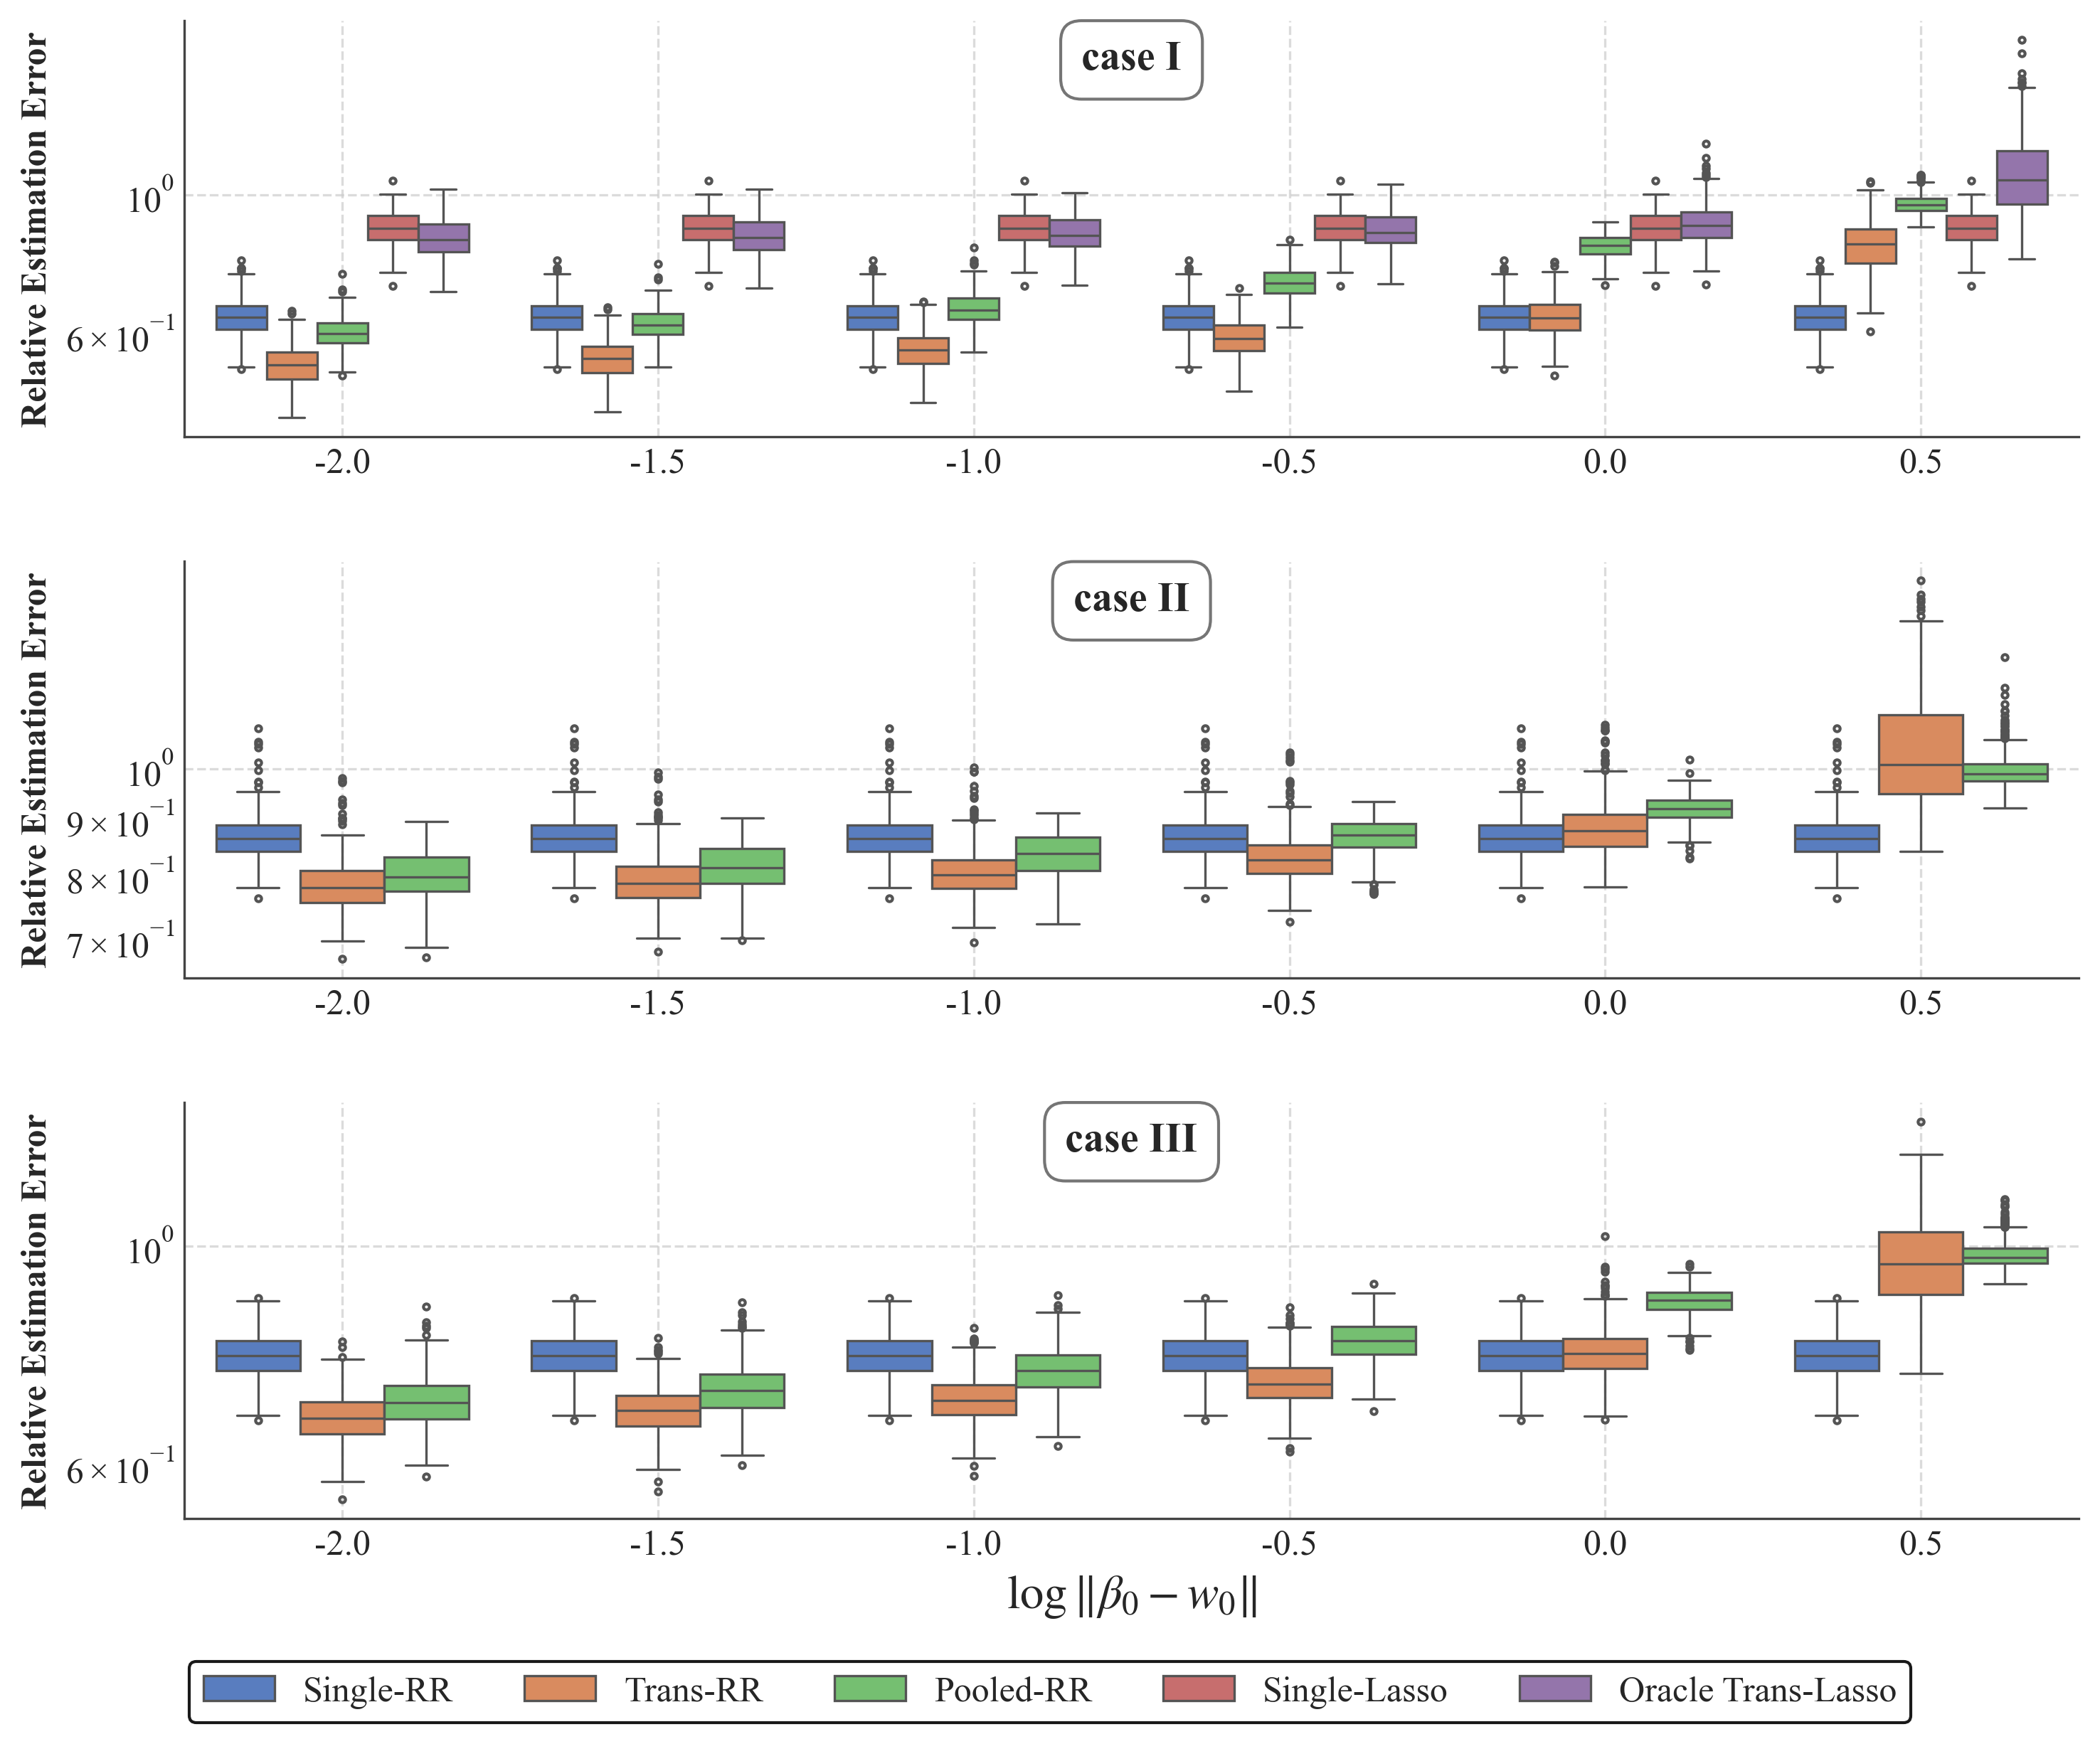

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json

# 设置matplotlib的字体和样式
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Palatino'],
    'font.size': 12,
    'mathtext.fontset': 'stix',
})

# 纯白色背景
bg_color = 'white'

# 加载数据
distribution_types = ['gaussian', 'cauchy', 'mix']
file_paths = [
    'res/gaussian_cv_results_p400_simu500.json',
    'res/cauchy_cv_results_p400_simu500.json',
    'res/mix_cv_results_p400_simu500.json'
]

# 准备一个大图，包含三个子图
fig, axes = plt.subplots(3, 1, figsize=(10, 8), dpi=300)

# 用于存储图例句柄和标签
legend_handles = None
legend_labels = None

# 方法名称映射
method_mapping = {
    'Single RR': 'Single-RR',
    'Trans RR': 'Trans-RR',
    'Pooled RR': 'Pooled-RR',
    'Single Lasso': 'Single-Lasso',
    'Trans Lasso': 'Oracle Trans-Lasso'
}

for idx, (dist_type, file_path) in enumerate(zip(distribution_types, file_paths)):
    # 加载JSON数据
    with open(file_path, 'r') as f:
        data = json.load(f)

    # 准备绘图数据
    all_data = []
    for dd_val_str in data:
        dd_val = float(dd_val_str)
        log_dd = np.log(1/dd_val)  # 使用对数变换作为x轴值

        # 从 results_df 获取数据
        results_dict = data[dd_val_str]['results_df']

        # 处理不同格式的 results_df
        if '0' in results_dict:  # 如果是行索引格式
            for method in results_dict.values():
                for method_name, errors in method.items():
                    for error_val in errors.values():
                        all_data.append({
                            'dd': dd_val,
                            'log_dd': log_dd,
                            'method': method_mapping.get(method_name, method_name),  # 转换方法名称
                            'error': error_val
                        })
        else:  # 如果是常规格式
            for method_name in results_dict:
                method_data = results_dict[method_name]
                for idx_str, error_val in method_data.items():
                    all_data.append({
                        'dd': dd_val,
                        'log_dd': log_dd,
                        'method': method_mapping.get(method_name, method_name),  # 转换方法名称
                        'error': error_val
                    })

    # 转换为DataFrame
    plot_data = pd.DataFrame(all_data)

    # 设置子图背景色
    ax = axes[idx]
    ax.set_facecolor(bg_color)

    # 创建分组箱线图，使用log_dd作为x轴
    sns.boxplot(
        x='log_dd',
        y='error',
        hue='method',
        data=plot_data,
        palette='muted',  # 原始的配色方案
        linewidth=0.8,
        fliersize=2,
        ax=ax
    )

    # 设置y轴标签 - 字体大小为12
    ax.set_ylabel('Relative Estimation Error', fontsize=12, fontweight='bold')

    # 只为最后一个子图设置x轴标签
    if idx == 2:  # 最后一个子图
        ax.set_xlabel(r'$\log \|\beta_0-w_0\|$', fontsize=16, fontweight='bold')
    else:
        ax.set_xlabel('')  # 移除前两个子图的x轴标签

    # 获取并设置x轴刻度 - 水平显示
    log_dd_values_sorted = sorted(plot_data['log_dd'].unique())
    ax.set_xticks(range(len(log_dd_values_sorted)))
    ax.set_xticklabels([f"{val:.1f}" for val in log_dd_values_sorted], rotation=0)

    # 设置y轴为对数尺度
    ax.set_yscale('log')

    # 减小y轴刻度的文字大小
    ax.tick_params(axis='y', labelsize=12)

    # 添加分布类型标题到图内上方中间位置
    dist_name = {'gaussian': 'case I', 'cauchy': 'case II', 'mix': 'case III'}
    ax.text(0.5, 0.95, f"{dist_name[dist_type]}",
            transform=ax.transAxes,
            ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#666666'),
            fontsize=14, fontweight='bold')

    # 移除标准标题
    ax.set_title("")

    # 添加灰色虚线网格背景
    ax.grid(True, linestyle='--', linewidth=0.8, color='#CCCCCC', alpha=0.7)
    ax.set_axisbelow(True)  # 确保网格在数据下方

    # 调整边框和样式
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_edgecolor('#444444')
    ax.tick_params(width=0.8)

    # 获取图例句柄和标签（只需要获取一次）
    if idx == 0:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    # 移除所有子图的图例
    ax.legend().remove()

# 调整布局
plt.tight_layout()
plt.subplots_adjust(hspace=0.3, bottom=0.1)  # 为底部图例留出空间

# 在整个图的底部添加图例，无标题
legend = fig.legend(legend_handles, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.03),
          ncol=len(legend_labels),  # 水平排列所有图例项
          framealpha=0.9,
          edgecolor='black',
          fancybox=True,
          fontsize=12)

# 为整个图形添加白色背景
fig.patch.set_facecolor('white')

# 保存图表
plt.savefig('res/methods_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)


# 显示图表
plt.show()